In [2]:
from pathlib import Path
import json
import platform
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from joblib import dump

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, KBinsDiscretizer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support, f1_score, log_loss
)

SEED = 42
np.random.seed(SEED)

OUT = Path("lab04_outputs")

for folder in ["figures", "models", "artifacts", "results"]:
    (OUT / folder).mkdir(parents=True, exist_ok=True)

versions = {
    "python": sys.version,
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__
}

(OUT / "artifacts" / "versions.json").write_text(
    json.dumps(versions, indent=2)
)

print("Environment configured successfully.")
print(json.dumps(versions, indent=2))

Environment configured successfully.
{
  "python": "3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]",
  "platform": "Windows-11-10.0.26200-SP0",
  "pandas": "2.2.3",
  "numpy": "2.5.1",
  "scikit_learn": "1.9.0"
}


In [4]:
# Load Dataset A

DATA_PATH = Path("Train.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)


# Check columns

print("Columns:")
print(df.columns.tolist())


# View data

display(df.head())


# Check target

TARGET = "Segmentation"

print("Target classes:")
print(df[TARGET].value_counts(dropna=False))


# Check data types

print("Data types:")
print(df.dtypes)


# Check missing values
print("Missing values:")
print(df.isnull().sum())


# Check duplicates

print("Exact duplicate rows:", df.duplicated().sum())


# Check ID

ID_COL = "ID"

print("Total rows:", len(df))
print("Unique IDs:", df[ID_COL].nunique())
print("Duplicate IDs:", df[ID_COL].duplicated().sum())

Dataset loaded successfully!
Shape: (8068, 11)
Columns:
['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation']


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


Target classes:
Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64
Data types:
ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
Segmentation        object
dtype: object
Missing values:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64
Exact duplicate rows: 0
Total rows: 8068
Unique IDs: 8068
Duplicate IDs: 0


In [34]:
# DATASET PROVENANCE + CHECKSUM

from pathlib import Path
import hashlib
import json
import pandas as pd
from datetime import datetime, timezone

# Create output folders if they don't exist
OUT = Path("lab04_outputs")
(OUT / "artifacts").mkdir(parents=True, exist_ok=True)
(OUT / "results").mkdir(parents=True, exist_ok=True)

# Target
TARGET = "Segmentation"

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()


train_path = Path("Train.csv")
test_path = Path("Test.csv")

if not train_path.exists():
    raise FileNotFoundError("Train.csv not found")

if not test_path.exists():
    raise FileNotFoundError("Test.csv not found")


train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)


dataset_provenance = {
    "dataset_name": "Customer Segmentation Dataset",
    "source_url":
        "https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation",
    "dataset_version": "Submission dataset pack",
    "train_file": train_path.name,
    "test_file": test_path.name,
    "train_rows": len(train_data),
    "test_rows": len(test_data),
    "train_columns": len(train_data.columns),
    "test_columns": len(test_data.columns),
    "train_sha256": sha256_file(train_path),
    "test_sha256": sha256_file(test_path),
    "target": TARGET,
    "accessed_utc":
        datetime.now(timezone.utc).isoformat()
}

with open(
    OUT / "artifacts" / "dataset_provenance.json",
    "w"
) as f:
    json.dump(dataset_provenance, f, indent=2)


print("DATASET PROVENANCE")
print("=" * 50)

for key, value in dataset_provenance.items():
    print(f"{key}: {value}")

print("\nDataset provenance saved successfully.")

DATASET PROVENANCE
dataset_name: Customer Segmentation Dataset
source_url: https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation
dataset_version: Submission dataset pack
train_file: Train.csv
test_file: Test.csv
train_rows: 8068
test_rows: 2627
train_columns: 11
test_columns: 10
train_sha256: 4245166ea666055eaeb151aecf2d16c346cdb230749eb064949684c965bf7355
test_sha256: 8dad4b0d365a8f8c73d2a1e28a91af5fd33adc036ad4e979cf61a51413d3d9ad
target: Segmentation
accessed_utc: 2026-08-22T18:06:54.664355+00:00

Dataset provenance saved successfully.


In [39]:
# ============================================================
# PUBLIC CUSTOMER DATASET DOCUMENTATION
# ============================================================

public_customer_datasets = pd.DataFrame([
    {
        "dataset": "Customer Segmentation Dataset",
        "source_url":
            "https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation",
        "target": "Segmentation",
        "supervised": True,
        "suitability":
            "Suitable for multiclass customer segmentation."
    },
    {
        "dataset": "UCI Bank Marketing",
        "source_url":
            "https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing",
        "target": "y",
        "supervised": True,
        "suitability":
            "Suitable for supervised customer/client response classification."
    },
    {
        "dataset": "UCI Online Shoppers Purchasing Intention",
        "source_url":
            "https://archive.ics.uci.edu/dataset/468/online%2Bshoppers%2Bpurchasing%2Bintention%2Bdataset",
        "target": "Revenue",
        "supervised": True,
        "suitability":
            "Suitable for supervised customer purchasing-intention classification."
    }
])

public_customer_datasets.to_csv(
    OUT / "results" /
    "public_customer_datasets.csv",
    index=False
)

display(public_customer_datasets)

assert len(public_customer_datasets) >= 3

print("Three public customer datasets documented.")

,dataset,source_url,target,supervised,suitability
0,Customer Segmentation Dataset,https://www.kaggle.com/datasets/kaushiksuresh1...,Segmentation,True,Suitable for multiclass customer segmentation.
1,UCI Bank Marketing,https://archive.ics.uci.edu/dataset/222/bank%2...,y,True,Suitable for supervised customer/client respon...
2,UCI Online Shoppers Purchasing Intention,https://archive.ics.uci.edu/dataset/468/online...,Revenue,True,Suitable for supervised customer purchasing-in...


Three public customer datasets documented.


In [35]:
# ============================================================
# LABEL DEFINITION
# ============================================================

label_definition = {
    "target": TARGET,
    "classes": sorted(
        train_data[TARGET].dropna().unique().tolist()
    ),
    "number_of_classes": int(
        train_data[TARGET].nunique()
    ),
    "supervised_target": True,
    "labels_fabricated": False,
    "definition":
        "Segmentation is the predefined customer-segment "
        "target supplied with the dataset."
}

with open(
    OUT / "artifacts" / "label_definition.json",
    "w"
) as f:
    json.dump(
        label_definition,
        f,
        indent=2
    )

print("LABEL DEFINITION")
print("=" * 50)

for key, value in label_definition.items():
    print(f"{key}: {value}")

print("\nLabel definition saved successfully.")

LABEL DEFINITION
target: Segmentation
classes: ['A', 'B', 'C', 'D']
number_of_classes: 4
supervised_target: True
labels_fabricated: False
definition: Segmentation is the predefined customer-segment target supplied with the dataset.

Label definition saved successfully.


In [6]:
# Create the feature groups

DEMOGRAPHIC = [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size"
]

BEHAVIORAL = [
    "Work_Experience",
    "Spending_Score"
]

OTHER = [
    "Var_1"
]

PSYCHOGRAPHIC = []

ALL_FEATURES = DEMOGRAPHIC + BEHAVIORAL + OTHER

print("Demographic features:")
print(DEMOGRAPHIC)

print("\nPsychographic features:")
print(PSYCHOGRAPHIC)

print("\nBehavioral features:")
print(BEHAVIORAL)

print("\nOther features:")
print(OTHER)

print("\nAll predictors:")
print(ALL_FEATURES)

Demographic features:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size']

Psychographic features:
[]

Behavioral features:
['Work_Experience', 'Spending_Score']

Other features:
['Var_1']

All predictors:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size', 'Work_Experience', 'Spending_Score', 'Var_1']


In [38]:
# ============================================================
# PSYCHOGRAPHIC PROVENANCE
# ============================================================

psychographic_provenance = {
    "psychographic_features": PSYCHOGRAPHIC,
    "self_reported": False,
    "survey_derived": False,
    "inferred": False,
    "status": "Not applicable",
    "reason":
        "The selected dataset contains no explicitly documented "
        "psychographic variables."
}

(OUT / "artifacts" /
 "psychographic_provenance.json").write_text(
    json.dumps(psychographic_provenance, indent=2)
)

print(json.dumps(
    psychographic_provenance,
    indent=2
))

print("Psychographic provenance documented.")

{
  "psychographic_features": [],
  "self_reported": false,
  "survey_derived": false,
  "inferred": false,
  "status": "Not applicable",
  "reason": "The selected dataset contains no explicitly documented psychographic variables."
}
Psychographic provenance documented.


In [7]:
# Verify that ID and target aren't predictors

assert "ID" not in ALL_FEATURES
assert TARGET not in ALL_FEATURES

print("ID excluded:", "ID" not in ALL_FEATURES)
print("Target excluded:", TARGET not in ALL_FEATURES)


# Check that all predictors actually exist

missing_features = [
    col for col in ALL_FEATURES
    if col not in df.columns
]

print("Missing configured features:", missing_features)


feature_manifest = {
    "demographic": DEMOGRAPHIC,
    "psychographic": PSYCHOGRAPHIC,
    "behavioral": BEHAVIORAL,
    "other": OTHER,
    "all_features": ALL_FEATURES,
    "excluded": ["ID"],
    "target": TARGET
}

print(json.dumps(feature_manifest, indent=2))

(OUT / "artifacts" / "feature_manifest.json").write_text(
    json.dumps(feature_manifest, indent=2)
)

print("\nFeature manifest saved.")

ID excluded: True
Target excluded: True
Missing configured features: []
{
  "demographic": [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size"
  ],
  "psychographic": [],
  "behavioral": [
    "Work_Experience",
    "Spending_Score"
  ],
  "other": [
    "Var_1"
  ],
  "all_features": [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size",
    "Work_Experience",
    "Spending_Score",
    "Var_1"
  ],
  "excluded": [
    "ID"
  ],
  "target": "Segmentation"
}

Feature manifest saved.


In [10]:
# Check feature cardinality

for col in ALL_FEATURES:
    print(
        f"{col:20} "
        f"Unique = {df[col].nunique(dropna=False):3} "
        f"Missing = {df[col].isna().sum():4}"
    )


# Create a complete feature summary

feature_summary = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Data_Type": [str(df[col].dtype) for col in ALL_FEATURES],
    "Group": (
        ["Demographic"] * len(DEMOGRAPHIC)
        + ["Behavioral"] * len(BEHAVIORAL)
        + ["Other"] * len(OTHER)
    ),
    "Missing_Count": [df[col].isna().sum() for col in ALL_FEATURES],
    "Missing_Percent": [
        df[col].isna().mean() * 100
        for col in ALL_FEATURES
    ],
    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in ALL_FEATURES
    ]
})

display(feature_summary)

feature_summary.to_csv(
    OUT / "results" / "feature_summary.csv",
    index=False
)

Gender               Unique =   2 Missing =    0
Ever_Married         Unique =   3 Missing =  140
Age                  Unique =  67 Missing =    0
Graduated            Unique =   3 Missing =   78
Profession           Unique =  10 Missing =  124
Family_Size          Unique =  10 Missing =  335
Work_Experience      Unique =  16 Missing =  829
Spending_Score       Unique =   3 Missing =    0
Var_1                Unique =   8 Missing =   76


,Feature,Data_Type,Group,Missing_Count,Missing_Percent,Unique_Values
0,Gender,object,Demographic,0,0.000000,2
1,Ever_Married,object,Demographic,140,1.735250,3
2,Age,int64,Demographic,0,0.000000,67
3,Graduated,object,Demographic,78,0.966782,3
4,Profession,object,Demographic,124,1.536936,10
5,Family_Size,float64,Demographic,335,4.152206,10
6,Work_Experience,float64,Behavioral,829,10.275161,16
7,Spending_Score,object,Behavioral,0,0.000000,3
8,Var_1,object,Other,76,0.941993,8


In [36]:
# ============================================================
# DATA DICTIONARY
# ============================================================

data_dictionary = pd.DataFrame([
    {
        "Feature": "ID",
        "Description": "Unique customer identifier",
        "Role": "Identifier",
        "Data_Type": str(train_data["ID"].dtype)
    },
    {
        "Feature": "Gender",
        "Description": "Gender of the customer",
        "Role": "Predictor",
        "Data_Type": str(train_data["Gender"].dtype)
    },
    {
        "Feature": "Ever_Married",
        "Description": "Whether the customer has ever been married",
        "Role": "Predictor",
        "Data_Type": str(train_data["Ever_Married"].dtype)
    },
    {
        "Feature": "Age",
        "Description": "Age of the customer",
        "Role": "Predictor",
        "Data_Type": str(train_data["Age"].dtype)
    },
    {
        "Feature": "Graduated",
        "Description": "Whether the customer is a graduate",
        "Role": "Predictor",
        "Data_Type": str(train_data["Graduated"].dtype)
    },
    {
        "Feature": "Profession",
        "Description": "Profession of the customer",
        "Role": "Predictor",
        "Data_Type": str(train_data["Profession"].dtype)
    },
    {
        "Feature": "Work_Experience",
        "Description": "Work experience of the customer",
        "Role": "Predictor",
        "Data_Type": str(train_data["Work_Experience"].dtype)
    },
    {
        "Feature": "Spending_Score",
        "Description": "Customer spending score",
        "Role": "Predictor",
        "Data_Type": str(train_data["Spending_Score"].dtype)
    },
    {
        "Feature": "Family_Size",
        "Description": "Number of family members",
        "Role": "Predictor",
        "Data_Type": str(train_data["Family_Size"].dtype)
    },
    {
        "Feature": "Var_1",
        "Description": "Anonymised customer category",
        "Role": "Predictor",
        "Data_Type": str(train_data["Var_1"].dtype)
    },
    {
        "Feature": "Segmentation",
        "Description": "Predefined customer segment",
        "Role": "Target",
        "Data_Type": str(train_data["Segmentation"].dtype)
    }
])

data_dictionary["Missing_Count"] = [
    train_data[row["Feature"]].isna().sum()
    for _, row in data_dictionary.iterrows()
]

data_dictionary["Unique_Values"] = [
    train_data[row["Feature"]].nunique(dropna=False)
    for _, row in data_dictionary.iterrows()
]

data_dictionary.to_csv(
    OUT / "results" / "data_dictionary.csv",
    index=False
)

display(data_dictionary)

print("Data dictionary saved successfully.")

,Feature,Description,Role,Data_Type,Missing_Count,Unique_Values
0,ID,Unique customer identifier,Identifier,int64,0,8068
1,Gender,Gender of the customer,Predictor,object,0,2
2,Ever_Married,Whether the customer has ever been married,Predictor,object,140,3
3,Age,Age of the customer,Predictor,int64,0,67
4,Graduated,Whether the customer is a graduate,Predictor,object,78,3
5,Profession,Profession of the customer,Predictor,object,124,10
6,Work_Experience,Work experience of the customer,Predictor,float64,829,16
7,Spending_Score,Customer spending score,Predictor,object,0,3
8,Family_Size,Number of family members,Predictor,float64,335,10
9,Var_1,Anonymised customer category,Predictor,object,76,8


Data dictionary saved successfully.


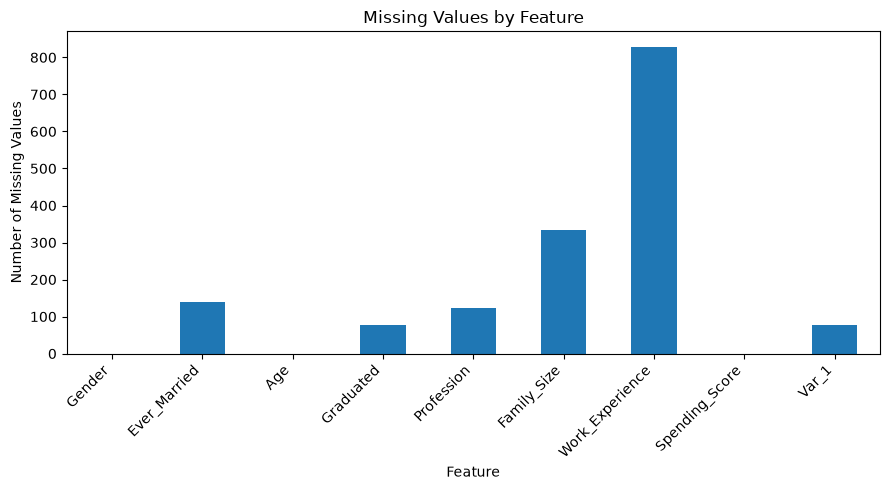

,Missing_Percent
Work_Experience,10.275161
Family_Size,4.152206
Ever_Married,1.735250
Profession,1.536936
Graduated,0.966782
Var_1,0.941993
Gender,0.000000
Age,0.000000
Spending_Score,0.000000


               Age  Work_Experience  Family_Size
count  8068.000000      7239.000000  7733.000000
mean     43.466906         2.641663     2.850123
std      16.711696         3.406763     1.531413
min      18.000000         0.000000     1.000000
25%      30.000000         0.000000     2.000000
50%      40.000000         1.000000     3.000000
75%      53.000000         4.000000     4.000000
max      89.000000        14.000000     9.000000


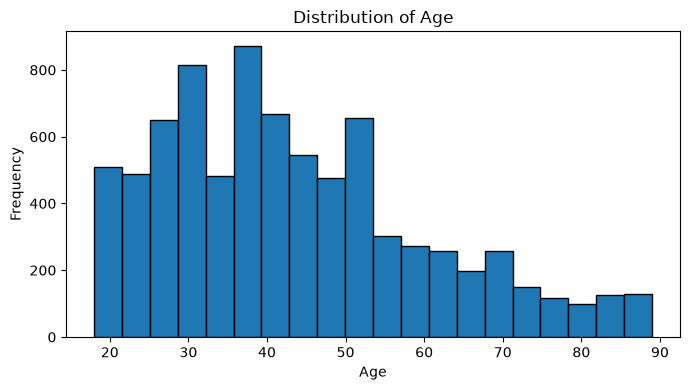

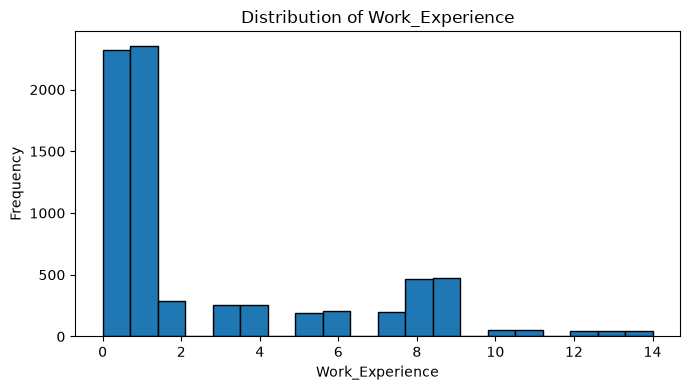

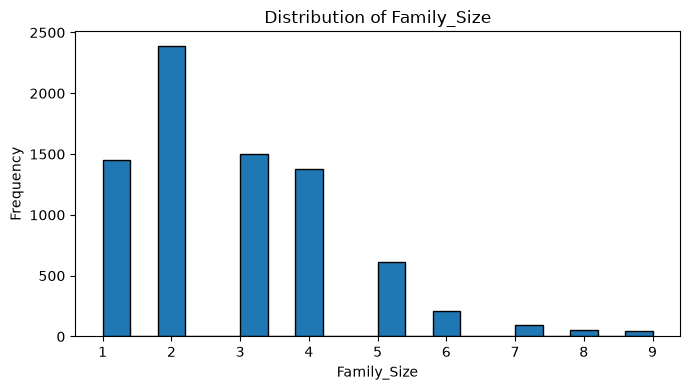

Categorical features:
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

Gender
Gender
Male      4417
Female    3651
Name: count, dtype: int64

Ever_Married
Ever_Married
Yes    4643
No     3285
NaN     140
Name: count, dtype: int64

Graduated
Graduated
Yes    4968
No     3022
NaN      78
Name: count, dtype: int64

Profession
Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
NaN               124
Name: count, dtype: int64

Spending_Score
Spending_Score
Low        4878
Average    1974
High       1216
Name: count, dtype: int64

Var_1
Var_1
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
NaN        76
Name: count, dtype: int64


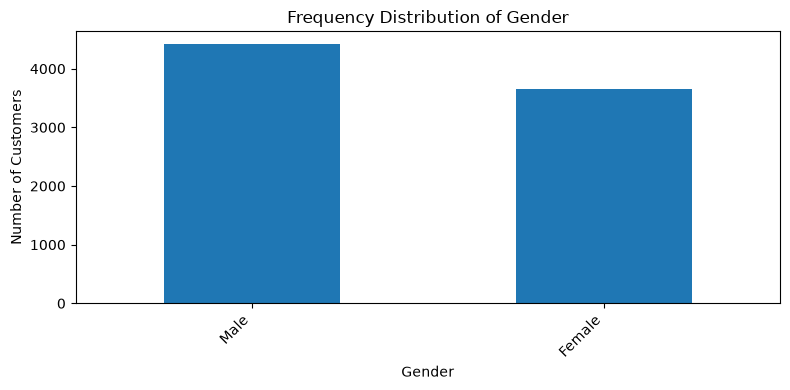

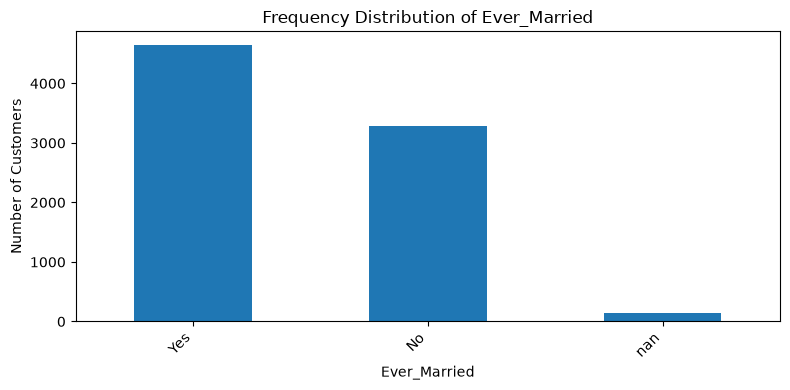

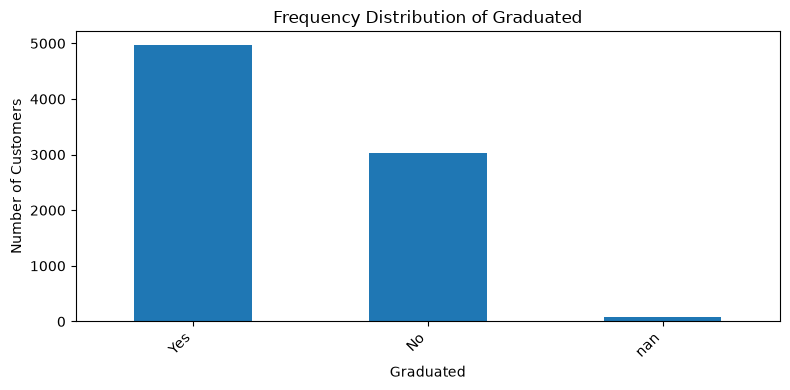

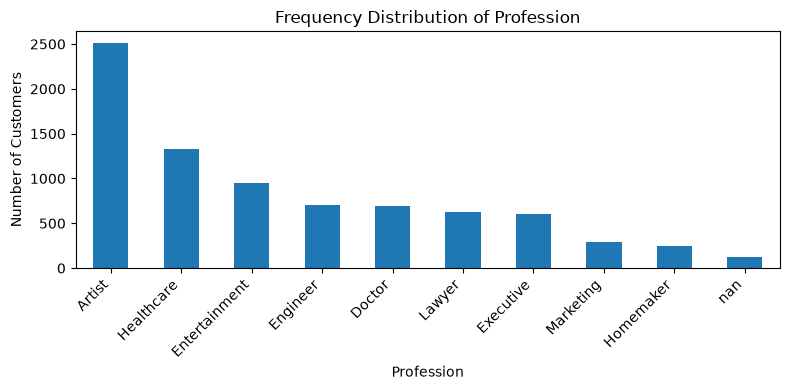

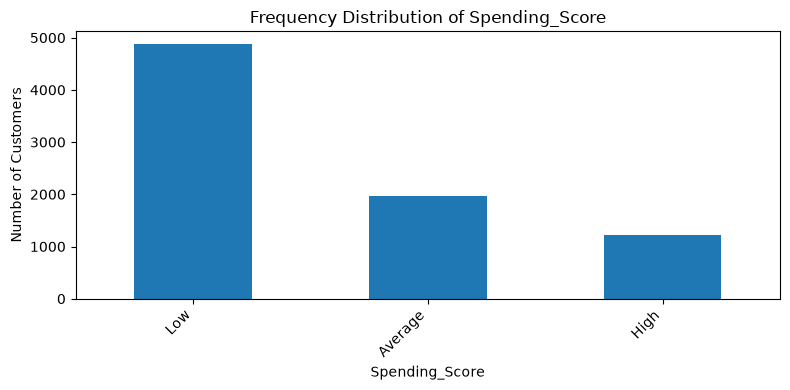

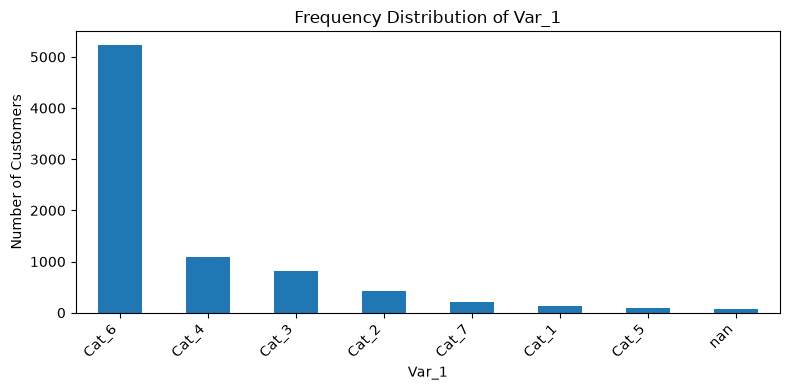

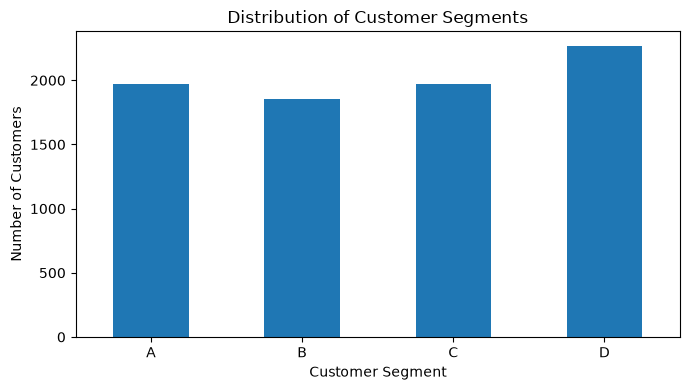

,Count,Percentage
Segmentation,,
A,1972,24.442241
B,1858,23.029251
C,1970,24.417452
D,2268,28.111056


Age Min = 18 Max = 89
Work_Experience Min = 0.0 Max = 14.0
Family_Size Min = 1.0 Max = 9.0
EDA summary saved successfully.


In [12]:
# Data Quality Analysis & Visualization

# Missing-value chart

missing = df[ALL_FEATURES].isnull().sum()

plt.figure(figsize=(9, 5))
missing.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(
    OUT / "figures" / "missing_values.png",
    dpi=180
)
plt.show()

# Missing-value percentage

missing_percent = (
    df[ALL_FEATURES].isnull().mean() * 100
).sort_values(ascending=False)


display(
    missing_percent.to_frame("Missing_Percent")
)

# Numerical features

NUMERIC = [
    "Age",
    "Work_Experience",
    "Family_Size"
]


print(df[NUMERIC].describe())

# Plot numerical distributions

for col in NUMERIC:


    plt.figure(figsize=(7, 4))


    df[col].dropna().plot(
        kind="hist",
        bins=20,
        edgecolor="black"
    )


    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")


    plt.tight_layout()


    plt.savefig(
        OUT / "figures" / f"{col}_distribution.png",
        dpi=180
    )


    plt.show()

# Define categorical features

CATEGORICAL = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Spending_Score",
    "Var_1"
]


print("Categorical features:")
print(CATEGORICAL)

# Check categorical values

for col in CATEGORICAL:
    print("\n", "=" * 40)
    print(col)
    print("=" * 40)


    print(df[col].value_counts(dropna=False))

# Categorical frequency plots

for col in CATEGORICAL:


    plt.figure(figsize=(8, 4))


    df[col].value_counts(dropna=False).plot(
        kind="bar"
    )


    plt.title(f"Frequency Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45, ha="right")


    plt.tight_layout()


    plt.savefig(
        OUT / "figures" / f"{col}_frequency.png",
        dpi=180
    )


    plt.show()

# Class-distribution graph

class_counts = df[TARGET].value_counts().sort_index()


plt.figure(figsize=(7, 4))


class_counts.plot(kind="bar")


plt.title("Distribution of Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)


plt.tight_layout()


plt.savefig(
    OUT / "figures" / "class_distribution.png",
    dpi=180
)


plt.show()

# Class percentages

class_percentage = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index() * 100
)


class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentage
})


display(class_summary)

# Check suspicious/implausible numerical values

for col in NUMERIC:
    print(
        col,
        "Min =", df[col].min(),
        "Max =", df[col].max()
    )

# Save EDA summary

eda_summary = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Missing_Count": [
        df[c].isna().sum()
        for c in ALL_FEATURES
    ],
    "Missing_Percent": [
        df[c].isna().mean() * 100
        for c in ALL_FEATURES
    ],
    "Unique_Values": [
        df[c].nunique(dropna=False)
        for c in ALL_FEATURES
    ]
})


eda_summary.to_csv(
    OUT / "results" / "eda_summary.csv",
    index=False
)


print("EDA summary saved successfully.")

In [2]:
# ============================================================
# DATA QUALITY AUDIT
# ============================================================

import os
import json
import numpy as np
import pandas as pd

print("=" * 70)
print("DATA QUALITY AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 0. Load dataset if df is not already available
# ------------------------------------------------------------

if "df" not in globals():
    if os.path.exists("Train.csv"):
        df = pd.read_csv("Train.csv")
    elif os.path.exists("/mnt/data/Train.csv"):
        df = pd.read_csv("/mnt/data/Train.csv")
    else:
        raise FileNotFoundError(
            "Train.csv was not found. Run the dataset loading cell first."
        )

print(f"\nDataset shape: {df.shape}")

# ------------------------------------------------------------
# 1. Define ID and target columns safely
# ------------------------------------------------------------

TARGET_COL = "Segmentation"

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' was not found.\n"
        f"Available columns: {list(df.columns)}"
    )

# Customer ID in this dataset
if "ID" in df.columns:
    ID_COL = "ID"
else:
    ID_COL = None

# ------------------------------------------------------------
# 2. Define ALL_FEATURES safely
# ------------------------------------------------------------

if "ALL_FEATURES" not in globals():

    DEMOGRAPHIC = [
        "Gender",
        "Ever_Married",
        "Age",
        "Graduated",
        "Profession",
        "Family_Size"
    ]

    BEHAVIORAL = [
        "Work_Experience",
        "Spending_Score"
    ]

    OTHER = [
        "Var_1"
    ]

    PSYCHOGRAPHIC = []

    ALL_FEATURES = (
        DEMOGRAPHIC
        + PSYCHOGRAPHIC
        + BEHAVIORAL
        + OTHER
    )

# Keep only features that actually exist in the dataset
ALL_FEATURES = [
    c for c in ALL_FEATURES
    if c in df.columns
]

print("\nFeatures used in audit:")
print(ALL_FEATURES)

# ------------------------------------------------------------
# 3. Constant features
# ------------------------------------------------------------

constant_features = [
    c for c in ALL_FEATURES
    if df[c].nunique(dropna=False) <= 1
]

print("\n" + "-" * 70)
print("1. CONSTANT FEATURES")
print("-" * 70)

if constant_features:
    print(constant_features)
else:
    print("None")

# ------------------------------------------------------------
# 4. Near-constant features
# ------------------------------------------------------------

near_constant_features = []

for c in ALL_FEATURES:

    value_counts = df[c].value_counts(
        dropna=False,
        normalize=True
    )

    if len(value_counts) > 0 and value_counts.iloc[0] >= 0.99:
        near_constant_features.append({
            "feature": c,
            "dominant_value": value_counts.index[0],
            "dominant_percentage": round(
                value_counts.iloc[0] * 100, 2
            )
        })

near_constant_df = pd.DataFrame(near_constant_features)

print("\n" + "-" * 70)
print("2. NEAR-CONSTANT FEATURES (>=99% SAME VALUE)")
print("-" * 70)

if near_constant_df.empty:
    print("None")
else:
    display(near_constant_df)

# ------------------------------------------------------------
# 5. Exact duplicate rows
# ------------------------------------------------------------

duplicate_rows_all = int(df.duplicated().sum())

print("\n" + "-" * 70)
print("3. EXACT DUPLICATE ROWS")
print("-" * 70)

print(f"Duplicate rows including ID: {duplicate_rows_all}")

# Duplicate customer profiles excluding ID
profile_columns = ALL_FEATURES + [TARGET_COL]

duplicate_profiles = int(
    df.duplicated(subset=profile_columns).sum()
)

print(
    f"Duplicate profiles excluding ID "
    f"(features + target): {duplicate_profiles}"
)

# ------------------------------------------------------------
# 6. Duplicate feature profiles excluding target
# ------------------------------------------------------------

duplicate_feature_profiles = int(
    df.duplicated(subset=ALL_FEATURES).sum()
)

print(
    f"Duplicate feature profiles excluding ID and target: "
    f"{duplicate_feature_profiles}"
)

# ------------------------------------------------------------
# 7. Missing values
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
    "feature": ALL_FEATURES,
    "missing_count": [
        int(df[c].isna().sum())
        for c in ALL_FEATURES
    ],
    "missing_percentage": [
        round(df[c].isna().mean() * 100, 2)
        for c in ALL_FEATURES
    ]
})

print("\n" + "-" * 70)
print("4. MISSING VALUE AUDIT")
print("-" * 70)

display(missing_summary)

# ------------------------------------------------------------
# 8. ID uniqueness
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("5. ID UNIQUENESS")
print("-" * 70)

if ID_COL is not None:

    unique_ids = df[ID_COL].nunique(dropna=False)
    total_rows = len(df)

    print(f"Total rows : {total_rows}")
    print(f"Unique IDs : {unique_ids}")

    if unique_ids == total_rows:
        print("Result: All IDs are unique.")
    else:
        print(
            f"WARNING: {total_rows - unique_ids} "
            f"duplicate ID occurrence(s) detected."
        )

else:
    print("No ID column found.")

# ------------------------------------------------------------
# 9. Numeric plausibility checks
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("6. NUMERIC PLAUSIBILITY AUDIT")
print("-" * 70)

plausibility_results = []

# Age
if "Age" in df.columns:

    invalid_age = (
        (df["Age"].notna()) &
        ((df["Age"] < 0) | (df["Age"] > 120))
    )

    plausibility_results.append({
        "feature": "Age",
        "rule": "0 <= Age <= 120",
        "invalid_count": int(invalid_age.sum())
    })

# Family Size
if "Family_Size" in df.columns:

    invalid_family = (
        (df["Family_Size"].notna()) &
        (df["Family_Size"] < 0)
    )

    plausibility_results.append({
        "feature": "Family_Size",
        "rule": "Family_Size >= 0",
        "invalid_count": int(invalid_family.sum())
    })

# Work Experience
if "Work_Experience" in df.columns:

    invalid_work = (
        (df["Work_Experience"].notna()) &
        (df["Work_Experience"] < 0)
    )

    plausibility_results.append({
        "feature": "Work_Experience",
        "rule": "Work_Experience >= 0",
        "invalid_count": int(invalid_work.sum())
    })

plausibility_df = pd.DataFrame(plausibility_results)

if not plausibility_df.empty:
    display(plausibility_df)
else:
    print("No numeric plausibility rules were applicable.")

# ------------------------------------------------------------
# 10. Categorical cardinality audit
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("7. CATEGORICAL CARDINALITY AUDIT")
print("-" * 70)

categorical_features = [
    c for c in ALL_FEATURES
    if df[c].dtype == "object"
]

cardinality_rows = []

for c in categorical_features:

    cardinality_rows.append({
        "feature": c,
        "unique_values": int(df[c].nunique(dropna=True)),
        "missing_values": int(df[c].isna().sum()),
        "top_value": (
            df[c].value_counts(dropna=True).index[0]
            if df[c].notna().any()
            else None
        )
    })

cardinality_df = pd.DataFrame(cardinality_rows)

if not cardinality_df.empty:
    display(cardinality_df)
else:
    print("No categorical features detected.")

# ------------------------------------------------------------
# 11. Sensitive / demographic attribute audit
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("8. SENSITIVE / DEMOGRAPHIC ATTRIBUTE AUDIT")
print("-" * 70)

demographic_features = [
    c for c in [
        "Gender",
        "Age",
        "Ever_Married",
        "Graduated",
        "Profession",
        "Family_Size"
    ]
    if c in df.columns
]

demographic_audit = []

for c in demographic_features:

    demographic_audit.append({
        "feature": c,
        "unique_values": int(df[c].nunique(dropna=True)),
        "missing": int(df[c].isna().sum()),
        "dtype": str(df[c].dtype)
    })

demographic_df = pd.DataFrame(demographic_audit)

display(demographic_df)

# ------------------------------------------------------------
# 12. Target distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("9. TARGET / LABEL AUDIT")
print("-" * 70)

target_counts = df[TARGET_COL].value_counts(
    dropna=False
).sort_index()

target_percentages = (
    df[TARGET_COL]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    * 100
)

target_audit = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

display(target_audit)

# ------------------------------------------------------------
# 13. Save audit results
# ------------------------------------------------------------

os.makedirs("lab04_outputs/artifacts", exist_ok=True)

audit_summary = {
    "dataset_shape": list(df.shape),
    "target_column": TARGET_COL,
    "id_column": ID_COL,
    "features": ALL_FEATURES,
    "constant_features": constant_features,
    "near_constant_features": (
        near_constant_df.to_dict(orient="records")
        if not near_constant_df.empty
        else []
    ),
    "exact_duplicate_rows": duplicate_rows_all,
    "duplicate_profiles": duplicate_profiles,
    "duplicate_feature_profiles": duplicate_feature_profiles,
    "missing_values": missing_summary.to_dict(orient="records"),
    "plausibility_checks": (
        plausibility_df.to_dict(orient="records")
        if not plausibility_df.empty
        else []
    ),
    "demographic_features": demographic_features,
    "target_distribution": target_audit.reset_index().to_dict(
        orient="records"
    )
}

with open(
    "lab04_outputs/artifacts/data_quality_audit.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        audit_summary,
        f,
        indent=2,
        default=str
    )

print("\n" + "=" * 70)
print("DATA QUALITY AUDIT COMPLETED")
print("=" * 70)

print(
    "\nSaved to:"
    "\nlab04_outputs/artifacts/data_quality_audit.json"
)

DATA QUALITY AUDIT

Dataset shape: (8068, 11)

Features used in audit:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size', 'Work_Experience', 'Spending_Score', 'Var_1']

----------------------------------------------------------------------
1. CONSTANT FEATURES
----------------------------------------------------------------------
None

----------------------------------------------------------------------
2. NEAR-CONSTANT FEATURES (>=99% SAME VALUE)
----------------------------------------------------------------------
None

----------------------------------------------------------------------
3. EXACT DUPLICATE ROWS
----------------------------------------------------------------------
Duplicate rows including ID: 0
Duplicate profiles excluding ID (features + target): 417
Duplicate feature profiles excluding ID and target: 734

----------------------------------------------------------------------
4. MISSING VALUE AUDIT
---------------------------------------

,feature,missing_count,missing_percentage
0,Gender,0,0.00
1,Ever_Married,140,1.74
2,Age,0,0.00
3,Graduated,78,0.97
4,Profession,124,1.54
5,Family_Size,335,4.15
6,Work_Experience,829,10.28
7,Spending_Score,0,0.00
8,Var_1,76,0.94



----------------------------------------------------------------------
5. ID UNIQUENESS
----------------------------------------------------------------------
Total rows : 8068
Unique IDs : 8068
Result: All IDs are unique.

----------------------------------------------------------------------
6. NUMERIC PLAUSIBILITY AUDIT
----------------------------------------------------------------------


,feature,rule,invalid_count
0,Age,0 <= Age <= 120,0
1,Family_Size,Family_Size >= 0,0
2,Work_Experience,Work_Experience >= 0,0



----------------------------------------------------------------------
7. CATEGORICAL CARDINALITY AUDIT
----------------------------------------------------------------------


...


----------------------------------------------------------------------
8. SENSITIVE / DEMOGRAPHIC ATTRIBUTE AUDIT
----------------------------------------------------------------------


,feature,unique_values,missing,dtype
0,Gender,2,0,object
1,Age,67,0,int64
2,Ever_Married,2,140,object
3,Graduated,2,78,object
4,Profession,9,124,object
5,Family_Size,9,335,float64



----------------------------------------------------------------------
9. TARGET / LABEL AUDIT
----------------------------------------------------------------------


,count,percentage
Segmentation,,
A,1972,24.44
B,1858,23.03
C,1970,24.42
D,2268,28.11



DATA QUALITY AUDIT COMPLETED

Saved to:
lab04_outputs/artifacts/data_quality_audit.json


In [3]:
# ============================================================
# LABEL PROVENANCE & CIRCULARITY AUDIT
# ============================================================

import os
import json
import pandas as pd

print("=" * 70)
print("LABEL PROVENANCE & CIRCULARITY AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Target definition
# ------------------------------------------------------------

TARGET_COL = "Segmentation"

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' not found in dataset."
    )

target_values = sorted(
    df[TARGET_COL].dropna().astype(str).unique().tolist()
)

print("\nTarget column:")
print(TARGET_COL)

print("\nObserved target classes:")
print(target_values)

# ------------------------------------------------------------
# 2. Label provenance
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("1. LABEL PROVENANCE")
print("-" * 70)

label_provenance = {
    "target_column": TARGET_COL,

    # Based on the notebook's documented dataset description
    "label_type": "Predefined categorical customer segment",

    "observed_classes": target_values,

    # Important: do not claim a generation rule that is not
    # documented by the supplied dataset.
    "label_generation_rule": (
        "Not independently reconstructed from the predictor variables. "
        "The supplied Segmentation field is treated as the predefined "
        "supervised-learning target."
    ),

    "labels_fabricated": False,

    "provenance_status": (
        "Target labels are taken directly from the supplied dataset. "
        "No labels are generated by this notebook."
    )
}

print(
    "\nLabel provenance status:"
)
print(label_provenance["provenance_status"])

# ------------------------------------------------------------
# 3. Feature / target circularity audit
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("2. FEATURE / TARGET CIRCULARITY AUDIT")
print("-" * 70)

# Reconstruct feature list safely
if "ALL_FEATURES" not in globals():

    DEMOGRAPHIC = [
        "Gender",
        "Ever_Married",
        "Age",
        "Graduated",
        "Profession",
        "Family_Size"
    ]

    BEHAVIORAL = [
        "Work_Experience",
        "Spending_Score"
    ]

    OTHER = [
        "Var_1"
    ]

    PSYCHOGRAPHIC = []

    ALL_FEATURES = (
        DEMOGRAPHIC
        + PSYCHOGRAPHIC
        + BEHAVIORAL
        + OTHER
    )

ALL_FEATURES = [
    c for c in ALL_FEATURES
    if c in df.columns and c != TARGET_COL
]

print("\nPredictor features:")
for feature in ALL_FEATURES:
    print("  -", feature)

# ------------------------------------------------------------
# 4. Direct target duplication check
# ------------------------------------------------------------

direct_target_duplicates = []

for feature in ALL_FEATURES:

    # Check whether a feature is literally identical to target
    feature_values = df[feature].astype(str)
    target_values_str = df[TARGET_COL].astype(str)

    identical = (
        feature_values == target_values_str
    ).mean()

    if identical == 1.0:
        direct_target_duplicates.append(feature)

print("\nDirect target duplicates:")

if direct_target_duplicates:
    print(direct_target_duplicates)
else:
    print("None detected.")

# ------------------------------------------------------------
# 5. Target encoded as a predictor check
# ------------------------------------------------------------

target_name_variants = {
    TARGET_COL.lower(),
    "segment",
    "customer_segment",
    "customersegment",
    "target",
    "label",
    "class"
}

suspicious_target_columns = [
    c for c in df.columns
    if c.lower() in target_name_variants
    and c != TARGET_COL
]

print("\nPotential target-derived columns based on column names:")

if suspicious_target_columns:
    print(suspicious_target_columns)
else:
    print("None detected.")

# ------------------------------------------------------------
# 6. Leakage-risk feature review
# ------------------------------------------------------------

leakage_review = []

for feature in ALL_FEATURES:

    name = feature.lower()

    risk = "Low"
    reason = (
        "Feature is treated as a predictor and is not explicitly "
        "identified as the target."
    )

    # These are warning flags only, not proof of leakage.
    leakage_keywords = [
        "segment",
        "target",
        "label",
        "class",
        "outcome",
        "prediction"
    ]

    if any(keyword in name for keyword in leakage_keywords):
        risk = "Review"
        reason = (
            "Feature name may indicate a target-derived or "
            "post-outcome variable; provenance should be verified."
        )

    leakage_review.append({
        "feature": feature,
        "risk": risk,
        "reason": reason
    })

leakage_review_df = pd.DataFrame(leakage_review)

display(leakage_review_df)

# ------------------------------------------------------------
# 7. Availability-before-label statement
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("3. FEATURE AVAILABILITY / LABEL CIRCULARITY")
print("-" * 70)

availability_statement = (
    "For this lab, the predictor variables are treated as inputs "
    "available before the predefined Segmentation label. The notebook "
    "does not use Segmentation to construct or transform predictor "
    "features."
)

print(availability_statement)

# ------------------------------------------------------------
# 8. Final audit conclusion
# ------------------------------------------------------------

if direct_target_duplicates:
    circularity_status = "FAIL"
elif suspicious_target_columns:
    circularity_status = "REVIEW"
else:
    circularity_status = "PASS"

print("\n" + "-" * 70)
print("4. AUDIT CONCLUSION")
print("-" * 70)

print(f"Circularity status: {circularity_status}")

if circularity_status == "PASS":
    print(
        "No direct target duplication was detected among the "
        "selected predictor variables."
    )

elif circularity_status == "REVIEW":
    print(
        "Potential target-derived columns require manual provenance "
        "verification before final submission."
    )

else:
    print(
        "Potential direct target duplication was detected. "
        "Investigate before proceeding."
    )

# ------------------------------------------------------------
# 9. Save audit artifact
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/artifacts",
    exist_ok=True
)

label_audit = {
    "target_column": TARGET_COL,
    "observed_classes": target_values,
    "label_provenance": label_provenance,
    "predictor_features": ALL_FEATURES,
    "direct_target_duplicates": direct_target_duplicates,
    "potential_target_columns": suspicious_target_columns,
    "leakage_review": leakage_review,
    "availability_statement": availability_statement,
    "circularity_status": circularity_status
}

label_audit_path = (
    "lab04_outputs/artifacts/"
    "label_provenance_circularity_audit.json"
)

with open(
    label_audit_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        label_audit,
        f,
        indent=2,
        default=str
    )

print("\nSaved:")
print(label_audit_path)

print("\n" + "=" * 70)
print("LABEL PROVENANCE & CIRCULARITY AUDIT COMPLETED")
print("=" * 70)

LABEL PROVENANCE & CIRCULARITY AUDIT

Target column:
Segmentation

Observed target classes:
['A', 'B', 'C', 'D']

----------------------------------------------------------------------
1. LABEL PROVENANCE
----------------------------------------------------------------------

Label provenance status:
Target labels are taken directly from the supplied dataset. No labels are generated by this notebook.

----------------------------------------------------------------------
2. FEATURE / TARGET CIRCULARITY AUDIT
----------------------------------------------------------------------

Predictor features:
  - Gender
  - Ever_Married
  - Age
  - Graduated
  - Profession
  - Family_Size
  - Work_Experience
  - Spending_Score
  - Var_1

Direct target duplicates:
None detected.

Potential target-derived columns based on column names:
None detected.


,feature,risk,reason
0,Gender,Low,Feature is treated as a predictor and is not e...
1,Ever_Married,Low,Feature is treated as a predictor and is not e...
2,Age,Low,Feature is treated as a predictor and is not e...
3,Graduated,Low,Feature is treated as a predictor and is not e...
4,Profession,Low,Feature is treated as a predictor and is not e...
5,Family_Size,Low,Feature is treated as a predictor and is not e...
6,Work_Experience,Low,Feature is treated as a predictor and is not e...
7,Spending_Score,Low,Feature is treated as a predictor and is not e...
8,Var_1,Low,Feature is treated as a predictor and is not e...



----------------------------------------------------------------------
3. FEATURE AVAILABILITY / LABEL CIRCULARITY
----------------------------------------------------------------------
For this lab, the predictor variables are treated as inputs available before the predefined Segmentation label. The notebook does not use Segmentation to construct or transform predictor features.

----------------------------------------------------------------------
4. AUDIT CONCLUSION
----------------------------------------------------------------------
Circularity status: PASS
No direct target duplication was detected among the selected predictor variables.

Saved:
lab04_outputs/artifacts/label_provenance_circularity_audit.json

LABEL PROVENANCE & CIRCULARITY AUDIT COMPLETED


In [5]:
# ============================================================
# RESTORE TRAIN / VALIDATION SPLIT
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold

print("=" * 70)
print("CREATING FIXED TRAIN / VALIDATION SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "df is not defined. Run the dataset loading cell first."
    )

TARGET_COL = "Segmentation"

if TARGET_COL not in df.columns:
    raise ValueError(
        f"{TARGET_COL} not found in dataset."
    )

# ------------------------------------------------------------
# ID column
# ------------------------------------------------------------

ID_COL = "ID" if "ID" in df.columns else None

# ------------------------------------------------------------
# Fixed 80/20 stratified split
# ------------------------------------------------------------

train_df, validation_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df[TARGET_COL],
    random_state=42
)

print(f"\nTotal dataset rows : {len(df)}")
print(f"Training rows      : {len(train_df)}")
print(f"Validation rows    : {len(validation_df)}")

# ------------------------------------------------------------
# Separate predictors and target
# ------------------------------------------------------------

X_train = train_df.drop(
    columns=[TARGET_COL] + ([ID_COL] if ID_COL else [])
).copy()

y_train = train_df[TARGET_COL].copy()

X_test = validation_df.drop(
    columns=[TARGET_COL] + ([ID_COL] if ID_COL else [])
).copy()

y_test = validation_df[TARGET_COL].copy()

# ------------------------------------------------------------
# Verify no ID leakage
# ------------------------------------------------------------

if ID_COL:

    train_ids = set(train_df[ID_COL])
    test_ids = set(validation_df[ID_COL])

    overlap = train_ids.intersection(test_ids)

    print(
        f"\nTrain/Test ID overlap: {len(overlap)}"
    )

    assert len(overlap) == 0, (
        "ERROR: Train/test ID overlap detected!"
    )

# ------------------------------------------------------------
# Create the SAME 5-fold CV object
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Verify class distributions
# ------------------------------------------------------------

print("\nTraining class distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nValidation class distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\n" + "=" * 70)
print("FIXED TRAIN / VALIDATION SPLIT READY")
print("=" * 70)

CREATING FIXED TRAIN / VALIDATION SPLIT

Total dataset rows : 8068
Training rows      : 6454
Validation rows    : 1614

Train/Test ID overlap: 0

Training class distribution:
Segmentation
A    0.2445
B    0.2302
C    0.2442
D    0.2811
Name: proportion, dtype: float64

Validation class distribution:
Segmentation
A    0.2441
B    0.2305
C    0.2441
D    0.2813
Name: proportion, dtype: float64

X_train shape: (6454, 9)
X_test shape : (1614, 9)

FIXED TRAIN / VALIDATION SPLIT READY


In [6]:
# ============================================================
# FEATURE-GROUP ABLATION STUDY
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    KBinsDiscretizer,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import make_scorer, f1_score

print("=" * 70)
print("FEATURE-GROUP ABLATION STUDY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Basic checks
# ------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "df is not defined. Run the dataset loading cell first."
    )

if "X_train" not in globals() or "y_train" not in globals():
    raise NameError(
        "X_train/y_train are not defined. "
        "Run the fixed train/validation split cell first."
    )

if "cv" not in globals():
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

TARGET_COL = "Segmentation"

# ------------------------------------------------------------
# 2. Define feature groups
# ------------------------------------------------------------

DEMOGRAPHIC = [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size"
]

PSYCHOGRAPHIC = []

BEHAVIORAL = [
    "Work_Experience",
    "Spending_Score"
]

OTHER = [
    "Var_1"
]

# Keep only columns actually present
DEMOGRAPHIC = [
    c for c in DEMOGRAPHIC if c in df.columns
]

PSYCHOGRAPHIC = [
    c for c in PSYCHOGRAPHIC if c in df.columns
]

BEHAVIORAL = [
    c for c in BEHAVIORAL if c in df.columns
]

OTHER = [
    c for c in OTHER if c in df.columns
]

COMBINED = list(dict.fromkeys(
    DEMOGRAPHIC
    + PSYCHOGRAPHIC
    + BEHAVIORAL
    + OTHER
))

feature_groups = {
    "Demographic": DEMOGRAPHIC,
    "Psychographic": PSYCHOGRAPHIC,
    "Behavioral": BEHAVIORAL,
    "Combined": COMBINED
}

print("\nFeature groups:")

for group_name, features in feature_groups.items():
    print(f"\n{group_name}:")
    if features:
        for feature in features:
            print(f"  - {feature}")
    else:
        print("  N/A - no explicitly documented psychographic variables")

# ------------------------------------------------------------
# 3. Build CategoricalNB pipeline for arbitrary feature subset
# ------------------------------------------------------------

def make_categorical_nb_ablation_pipeline(columns):

    columns = list(columns)

    if not columns:
        return None

    numeric_features = [
        c for c in columns
        if pd.api.types.is_numeric_dtype(df[c])
    ]

    categorical_features = [
        c for c in columns
        if c not in numeric_features
    ]

    transformers = []

    # --------------------------------------------------------
    # Numeric features
    # --------------------------------------------------------

    if numeric_features:

        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "binning",
                KBinsDiscretizer(
                    n_bins=5,
                    encode="ordinal",
                    strategy="quantile"
                )
            ),
            (
                "to_nonnegative",
                FunctionTransformer(
                    lambda X: np.asarray(X).astype(np.int64)
                )
            )
        ])

        transformers.append(
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            )
        )

    # --------------------------------------------------------
    # Categorical features
    # --------------------------------------------------------

    if categorical_features:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "ordinal",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            ),
            (
                "shift_nonnegative",
                FunctionTransformer(
                    lambda X: np.asarray(X).astype(np.int64) + 1
                )
            )
        ])

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            CategoricalNB()
        )
    ])

    return pipeline


# ------------------------------------------------------------
# 4. Run ablation
# ------------------------------------------------------------

ablation_results = []

for group_name, features in feature_groups.items():

    print("\n" + "-" * 70)
    print(f"GROUP: {group_name}")
    print("-" * 70)

    # Psychographic group is not available
    if not features:

        print(
            "Skipped: no explicitly documented psychographic "
            "variables are available in this dataset."
        )

        ablation_results.append({
            "feature_group": group_name,
            "status": "N/A",
            "n_features": 0,
            "features": "",
            "mean_macro_f1": np.nan,
            "std_macro_f1": np.nan
        })

        continue

    print("Features:")
    print(features)

    # IMPORTANT:
    # Use only the selected columns
    X_group = X_train[features].copy()

    # Build a fresh pipeline for this exact feature subset
    pipeline = make_categorical_nb_ablation_pipeline(
        features
    )

    # --------------------------------------------------------
    # Cross-validation
    # --------------------------------------------------------

    scoring = {
        "macro_f1": make_scorer(
            f1_score,
            average="macro"
        )
    }

    start_time = time.perf_counter()

    cv_result = cross_validate(
        pipeline,
        X_group,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    elapsed = time.perf_counter() - start_time

    fold_scores = cv_result["test_macro_f1"]

    mean_f1 = fold_scores.mean()
    std_f1 = fold_scores.std(ddof=1)

    print("\nFold Macro F1:")
    for i, score in enumerate(fold_scores, start=1):
        print(
            f"Fold {i}: {score:.6f}"
        )

    print(
        f"\nMean Macro F1: {mean_f1:.6f}"
    )

    print(
        f"SD Macro F1:   {std_f1:.6f}"
    )

    print(
        f"CV runtime:    {elapsed:.2f} seconds"
    )

    ablation_results.append({
        "feature_group": group_name,
        "status": "Evaluated",
        "n_features": len(features),
        "features": ", ".join(features),
        "fold_1_macro_f1": fold_scores[0],
        "fold_2_macro_f1": fold_scores[1],
        "fold_3_macro_f1": fold_scores[2],
        "fold_4_macro_f1": fold_scores[3],
        "fold_5_macro_f1": fold_scores[4],
        "mean_macro_f1": mean_f1,
        "std_macro_f1": std_f1,
        "cv_runtime_seconds": elapsed
    })


# ------------------------------------------------------------
# 5. Results table
# ------------------------------------------------------------

ablation_df = pd.DataFrame(ablation_results)

print("\n" + "=" * 70)
print("FEATURE-GROUP ABLATION RESULTS")
print("=" * 70)

display(ablation_df)

# ------------------------------------------------------------
# 6. Identify best evaluated feature group
# ------------------------------------------------------------

evaluated_ablation = ablation_df[
    ablation_df["status"] == "Evaluated"
].copy()

if not evaluated_ablation.empty:

    best_group_row = evaluated_ablation.loc[
        evaluated_ablation["mean_macro_f1"].idxmax()
    ]

    best_group = best_group_row["feature_group"]
    best_group_score = best_group_row["mean_macro_f1"]

    print(
        f"\nBest evaluated feature group: "
        f"{best_group}"
    )

    print(
        f"Mean CV Macro F1: "
        f"{best_group_score:.6f}"
    )

else:

    best_group = None

    print(
        "\nNo feature group could be evaluated."
    )

# ------------------------------------------------------------
# 7. Save results
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/results",
    exist_ok=True
)

ablation_csv = (
    "lab04_outputs/results/"
    "feature_group_ablation.csv"
)

ablation_df.to_csv(
    ablation_csv,
    index=False
)

# ------------------------------------------------------------
# 8. Save feature-group manifest
# ------------------------------------------------------------

feature_group_manifest = {
    "Demographic": DEMOGRAPHIC,
    "Psychographic": PSYCHOGRAPHIC,
    "Behavioral": BEHAVIORAL,
    "Other": OTHER,
    "Combined": COMBINED,
    "psychographic_status": (
        "N/A - no explicitly documented psychographic "
        "variables in the supplied dataset"
    )
}

manifest_path = (
    "lab04_outputs/artifacts/"
    "feature_group_manifest.json"
)

os.makedirs(
    "lab04_outputs/artifacts",
    exist_ok=True
)

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        feature_group_manifest,
        f,
        indent=2
    )

print("\nSaved:")
print(ablation_csv)
print(manifest_path)

# ------------------------------------------------------------
# 9. Lab-report interpretation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

if "Combined" in evaluated_ablation["feature_group"].values:

    combined_row = evaluated_ablation[
        evaluated_ablation["feature_group"] == "Combined"
    ].iloc[0]

    print(
        f"\nThe combined feature set achieved a mean "
        f"5-fold CV Macro F1 of "
        f"{combined_row['mean_macro_f1']:.4f} "
        f"(SD = {combined_row['std_macro_f1']:.4f})."
    )

if "Demographic" in evaluated_ablation["feature_group"].values:

    demographic_row = evaluated_ablation[
        evaluated_ablation["feature_group"] == "Demographic"
    ].iloc[0]

    print(
        f"The demographic-only feature set achieved "
        f"Macro F1 = "
        f"{demographic_row['mean_macro_f1']:.4f}."
    )

if "Behavioral" in evaluated_ablation["feature_group"].values:

    behavioral_row = evaluated_ablation[
        evaluated_ablation["feature_group"] == "Behavioral"
    ].iloc[0]

    print(
        f"The behavioral-only feature set achieved "
        f"Macro F1 = "
        f"{behavioral_row['mean_macro_f1']:.4f}."
    )

print(
    "\nPsychographic ablation: N/A. "
    "The supplied dataset does not contain explicitly documented "
    "psychographic variables, so none were fabricated for this study."
)

print(
    "\nIMPORTANT: Feature-group ablation is interpreted as an "
    "observational comparison of predictive performance. "
    "It does not establish causal importance of individual features."
)

print("\n" + "=" * 70)
print("FEATURE-GROUP ABLATION COMPLETED")
print("=" * 70)

FEATURE-GROUP ABLATION STUDY

Feature groups:

Demographic:
  - Gender
  - Ever_Married
  - Age
  - Graduated
  - Profession
  - Family_Size

Psychographic:
  N/A - no explicitly documented psychographic variables

Behavioral:
  - Work_Experience
  - Spending_Score

Combined:
  - Gender
  - Ever_Married
  - Age
  - Graduated
  - Profession
  - Family_Size
  - Work_Experience
  - Spending_Score
  - Var_1

----------------------------------------------------------------------
GROUP: Demographic
----------------------------------------------------------------------
Features:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size']

Fold Macro F1:
Fold 1: 0.488611
Fold 2: 0.476240
Fold 3: 0.480483
Fold 4: 0.468191
Fold 5: 0.487683

Mean Macro F1: 0.480242
SD Macro F1:   0.008466
CV runtime:    9.73 seconds

----------------------------------------------------------------------
GROUP: Psychographic
----------------------------------------------------------------------
Ski

,feature_group,status,n_features,features,fold_1_macro_f1,fold_2_macro_f1,fold_3_macro_f1,fold_4_macro_f1,fold_5_macro_f1,mean_macro_f1,std_macro_f1,cv_runtime_seconds
0,Demographic,Evaluated,6,"Gender, Ever_Married, Age, Graduated, Professi...",0.488611,0.476240,0.480483,0.468191,0.487683,0.480242,0.008466,9.734095
1,Psychographic,N/A,0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Behavioral,Evaluated,2,"Work_Experience, Spending_Score",0.264070,0.251795,0.309829,0.270733,0.266487,0.272583,0.021980,6.482640
3,Combined,Evaluated,9,"Gender, Ever_Married, Age, Graduated, Professi...",0.496391,0.470988,0.490296,0.487131,0.477811,0.484523,0.010115,0.273997



Best evaluated feature group: Combined
Mean CV Macro F1: 0.484523

Saved:
lab04_outputs/results/feature_group_ablation.csv
lab04_outputs/artifacts/feature_group_manifest.json

INTERPRETATION

The combined feature set achieved a mean 5-fold CV Macro F1 of 0.4845 (SD = 0.0101).
The demographic-only feature set achieved Macro F1 = 0.4802.
The behavioral-only feature set achieved Macro F1 = 0.2726.

Psychographic ablation: N/A. The supplied dataset does not contain explicitly documented psychographic variables, so none were fabricated for this study.

IMPORTANT: Feature-group ablation is interpreted as an observational comparison of predictive performance. It does not establish causal importance of individual features.

FEATURE-GROUP ABLATION COMPLETED


In [8]:
# ============================================================
# SELF-CONTAINED CV CLASS-WISE METRICS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    KBinsDiscretizer,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.naive_bayes import (
    GaussianNB,
    BernoulliNB,
    CategoricalNB
)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    precision_recall_fscore_support,
    f1_score
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("CROSS-VALIDATION CLASS-WISE METRICS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check train data
# ------------------------------------------------------------

if "X_train" not in globals() or "y_train" not in globals():
    raise NameError(
        "X_train/y_train are missing. "
        "Run the RESTORE TRAIN / VALIDATION SPLIT cell first."
    )

# ------------------------------------------------------------
# 2. Feature definitions
# ------------------------------------------------------------

ALL_FEATURES = [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Work_Experience",
    "Spending_Score",
    "Family_Size",
    "Var_1"
]

ALL_FEATURES = [
    c for c in ALL_FEATURES
    if c in X_train.columns
]

X_cv = X_train[ALL_FEATURES].copy()

numeric_features = [
    c for c in ALL_FEATURES
    if pd.api.types.is_numeric_dtype(X_cv[c])
]

categorical_features = [
    c for c in ALL_FEATURES
    if c not in numeric_features
]

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def to_integer(X):
    return np.asarray(X).astype(np.int64)


def shift_nonnegative(X):
    return np.asarray(X).astype(np.int64) + 1


# ------------------------------------------------------------
# 4. Dummy / Bernoulli preprocessing
# ------------------------------------------------------------

numeric_bernoulli = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "bin",
        KBinsDiscretizer(
            n_bins=5,
            encode="onehot-dense",
            strategy="quantile"
        )
    )
])

categorical_bernoulli = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

bernoulli_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_bernoulli,
        numeric_features
    ),
    (
        "categorical",
        categorical_bernoulli,
        categorical_features
    )
])

# ------------------------------------------------------------
# 5. Gaussian preprocessing
# ------------------------------------------------------------

# GaussianNB is applied to continuous numeric variables.
gaussian_preprocessor = ColumnTransformer([
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numeric_features
    )
])

# ------------------------------------------------------------
# 6. CategoricalNB mixed-feature preprocessing
# ------------------------------------------------------------

numeric_categorical = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "bin",
        KBinsDiscretizer(
            n_bins=5,
            encode="ordinal",
            strategy="quantile"
        )
    ),
    (
        "integer",
        FunctionTransformer(to_integer)
    )
])

categorical_categorical = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "ordinal",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
    (
        "nonnegative",
        FunctionTransformer(shift_nonnegative)
    )
])

categorical_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_categorical,
        numeric_features
    ),
    (
        "categorical",
        categorical_categorical,
        categorical_features
    )
])

# ------------------------------------------------------------
# 7. Build the four required core pipelines
# ------------------------------------------------------------

core_pipelines = {

    "Dummy": Pipeline([
        (
            "preprocessor",
            bernoulli_preprocessor
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]),

    "GaussianNB": Pipeline([
        (
            "preprocessor",
            gaussian_preprocessor
        ),
        (
            "classifier",
            GaussianNB()
        )
    ]),

    "BernoulliNB": Pipeline([
        (
            "preprocessor",
            bernoulli_preprocessor
        ),
        (
            "classifier",
            BernoulliNB()
        )
    ]),

    "CategoricalNB_mixed": Pipeline([
        (
            "preprocessor",
            categorical_preprocessor
        ),
        (
            "classifier",
            CategoricalNB()
        )
    ])
}

print("\nCore pipelines created:")
for name in core_pipelines:
    print(" -", name)

# ------------------------------------------------------------
# 8. SAME fixed 5-fold CV
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 9. OOF class-wise metrics
# ------------------------------------------------------------

labels = sorted(
    y_train.dropna().unique().tolist()
)

all_results = []
model_macro_results = []

for model_name, pipeline in core_pipelines.items():

    print("\n" + "-" * 70)
    print(f"MODEL: {model_name}")
    print("-" * 70)

    y_oof_pred = cross_val_predict(
        pipeline,
        X_cv,
        y_train,
        cv=cv,
        method="predict",
        n_jobs=-1
    )

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_train,
            y_oof_pred,
            labels=labels,
            zero_division=0
        )
    )

    macro_f1 = f1_score(
        y_train,
        y_oof_pred,
        average="macro"
    )

    model_macro_results.append({
        "model": model_name,
        "oof_macro_f1": macro_f1
    })

    temp = pd.DataFrame({
        "model": model_name,
        "class": labels,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    })

    all_results.append(temp)

    print(f"\nOOF Macro F1 = {macro_f1:.6f}")

    display(
        temp.style.format({
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}"
        })
    )

# ------------------------------------------------------------
# 10. Combined class-wise table
# ------------------------------------------------------------

classwise_cv_df = pd.concat(
    all_results,
    ignore_index=True
)

model_macro_df = pd.DataFrame(
    model_macro_results
).sort_values(
    "oof_macro_f1",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL OOF MACRO F1 SUMMARY")
print("=" * 70)

display(
    model_macro_df.style.format({
        "oof_macro_f1": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 11. Selected model
# ------------------------------------------------------------

selected_model_name = model_macro_df.iloc[0]["model"]

selected_classwise_df = classwise_cv_df[
    classwise_cv_df["model"] == selected_model_name
].copy()

print("\n" + "=" * 70)
print("SELECTED MODEL")
print("=" * 70)

print(f"\nSelected model: {selected_model_name}")

print(
    f"OOF Macro F1: "
    f"{model_macro_df.iloc[0]['oof_macro_f1']:.6f}"
)

print("\nClass-wise performance:")

display(
    selected_classwise_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 12. Identify weakest class by recall
# ------------------------------------------------------------

weakest_row = selected_classwise_df.loc[
    selected_classwise_df["recall"].idxmin()
]

print("\n" + "-" * 70)
print("WEAKEST CLASS BY RECALL")
print("-" * 70)

print(
    f"Class: {weakest_row['class']}"
)

print(
    f"Recall: {weakest_row['recall']:.4f}"
)

print(
    f"F1: {weakest_row['f1']:.4f}"
)

print(
    "\nThis class requires particular attention because "
    "a larger proportion of its true customers are missed."
)

# ------------------------------------------------------------
# 13. Save results
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/results",
    exist_ok=True
)

classwise_cv_df.to_csv(
    "lab04_outputs/results/cv_classwise_metrics.csv",
    index=False
)

model_macro_df.to_csv(
    "lab04_outputs/results/cv_model_macro_f1.csv",
    index=False
)

selected_classwise_df.to_csv(
    "lab04_outputs/results/"
    "selected_model_cv_classwise_metrics.csv",
    index=False
)

print("\nSaved:")
print("lab04_outputs/results/cv_classwise_metrics.csv")
print("lab04_outputs/results/cv_model_macro_f1.csv")
print(
    "lab04_outputs/results/"
    "selected_model_cv_classwise_metrics.csv"
)

print("\n" + "=" * 70)
print("CV CLASS-WISE METRICS COMPLETED")
print("=" * 70)

CROSS-VALIDATION CLASS-WISE METRICS

Numeric features:
['Age', 'Work_Experience', 'Family_Size']

Categorical features:
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

Core pipelines created:
 - Dummy
 - GaussianNB
 - BernoulliNB
 - CategoricalNB_mixed

----------------------------------------------------------------------
MODEL: Dummy
----------------------------------------------------------------------

OOF Macro F1 = 0.109700


,model,class,precision,recall,f1,support
0,Dummy,A,0.0000,0.0000,0.0000,1578
1,Dummy,B,0.0000,0.0000,0.0000,1486
2,Dummy,C,0.0000,0.0000,0.0000,1576
3,Dummy,D,0.2811,1.0000,0.4388,1814



----------------------------------------------------------------------
MODEL: GaussianNB
----------------------------------------------------------------------

OOF Macro F1 = 0.372785


,model,class,precision,recall,f1,support
0,GaussianNB,A,0.3501,0.2212,0.2711,1578
1,GaussianNB,B,0.2844,0.1211,0.1699,1486
2,GaussianNB,C,0.3974,0.5393,0.4576,1576
3,GaussianNB,D,0.4965,0.7348,0.5926,1814



----------------------------------------------------------------------
MODEL: BernoulliNB
----------------------------------------------------------------------

OOF Macro F1 = 0.480081


...


MODEL OOF MACRO F1 SUMMARY


,model,oof_macro_f1
0,CategoricalNB_mixed,0.484546
1,BernoulliNB,0.480081
2,GaussianNB,0.372785
3,Dummy,0.109700



SELECTED MODEL

Selected model: CategoricalNB_mixed
OOF Macro F1: 0.484546

Class-wise performance:


,model,class,precision,recall,f1,support
12,CategoricalNB_mixed,A,0.4406,0.4373,0.4389,1578
13,CategoricalNB_mixed,B,0.3810,0.2153,0.2752,1486
14,CategoricalNB_mixed,C,0.4952,0.6612,0.5663,1576
15,CategoricalNB_mixed,D,0.6358,0.6814,0.6578,1814



----------------------------------------------------------------------
WEAKEST CLASS BY RECALL
----------------------------------------------------------------------
Class: B
Recall: 0.2153
F1: 0.2752

This class requires particular attention because a larger proportion of its true customers are missed.

Saved:
lab04_outputs/results/cv_classwise_metrics.csv
lab04_outputs/results/cv_model_macro_f1.csv
lab04_outputs/results/selected_model_cv_classwise_metrics.csv

CV CLASS-WISE METRICS COMPLETED


In [9]:
# ============================================================
# TRAINING AND INFERENCE TIME
# ============================================================

import os
import time
import numpy as np
import pandas as pd

print("=" * 70)
print("TRAINING AND INFERENCE TIME")
print("=" * 70)

# ------------------------------------------------------------
# 1. Required variables
# ------------------------------------------------------------

required = [
    "X_train",
    "y_train",
    "X_test",
    "y_test",
    "core_pipelines"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise NameError(
        "Missing variables: " + ", ".join(missing)
    )

# ------------------------------------------------------------
# 2. Use the selected feature set
# ------------------------------------------------------------

if "selected_features" in globals():
    timing_features = list(selected_features)
else:
    timing_features = [
        c for c in ALL_FEATURES
        if c in X_train.columns
    ]

X_timing_train = X_train[timing_features].copy()
X_timing_test = X_test[timing_features].copy()

print("\nFeatures used:")
print(timing_features)

# ------------------------------------------------------------
# 3. Determine selected model
# ------------------------------------------------------------

if "selected_model_name" in globals():
    selected_for_timing = selected_model_name
elif "selected_name" in globals():
    selected_for_timing = selected_name
else:
    selected_for_timing = "CategoricalNB_mixed"

if selected_for_timing not in core_pipelines:
    raise ValueError(
        f"Selected model '{selected_for_timing}' "
        f"is not available."
    )

print(
    f"\nSelected model: {selected_for_timing}"
)

# ------------------------------------------------------------
# 4. Measure all four models
# ------------------------------------------------------------

timing_results = []

for model_name, pipeline in core_pipelines.items():

    print("\n" + "-" * 70)
    print(f"MODEL: {model_name}")
    print("-" * 70)

    # --------------------------------------------------------
    # Fresh pipeline for fair timing
    # --------------------------------------------------------

    import copy

    model_pipeline = copy.deepcopy(pipeline)

    # --------------------------------------------------------
    # Training time
    # --------------------------------------------------------

    start_train = time.perf_counter()

    model_pipeline.fit(
        X_timing_train,
        y_train
    )

    training_time = (
        time.perf_counter() - start_train
    )

    # --------------------------------------------------------
    # Inference time
    # --------------------------------------------------------

    start_predict = time.perf_counter()

    predictions = model_pipeline.predict(
        X_timing_test
    )

    inference_time = (
        time.perf_counter() - start_predict
    )

    # --------------------------------------------------------
    # Per-record inference time
    # --------------------------------------------------------

    n_test = len(X_timing_test)

    inference_ms_per_record = (
        inference_time / n_test
    ) * 1000

    print(
        f"Training time: "
        f"{training_time:.6f} seconds"
    )

    print(
        f"Total inference time: "
        f"{inference_time:.6f} seconds"
    )

    print(
        f"Inference per record: "
        f"{inference_ms_per_record:.6f} ms"
    )

    timing_results.append({
        "model": model_name,
        "training_time_seconds": training_time,
        "inference_time_seconds": inference_time,
        "inference_ms_per_record": inference_ms_per_record,
        "n_training_records": len(X_timing_train),
        "n_inference_records": n_test
    })

# ------------------------------------------------------------
# 5. Results table
# ------------------------------------------------------------

timing_df = pd.DataFrame(timing_results)

print("\n" + "=" * 70)
print("TIMING RESULTS")
print("=" * 70)

display(
    timing_df.style.format({
        "training_time_seconds": "{:.6f}",
        "inference_time_seconds": "{:.6f}",
        "inference_ms_per_record": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 6. Selected model timing
# ------------------------------------------------------------

selected_timing = timing_df[
    timing_df["model"] == selected_for_timing
].copy()

print("\n" + "=" * 70)
print("SELECTED MODEL TIMING")
print("=" * 70)

display(
    selected_timing.style.format({
        "training_time_seconds": "{:.6f}",
        "inference_time_seconds": "{:.6f}",
        "inference_ms_per_record": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 7. Save timing results
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/results",
    exist_ok=True
)

timing_path = (
    "lab04_outputs/results/"
    "training_inference_timing.csv"
)

timing_df.to_csv(
    timing_path,
    index=False
)

print("\nSaved:")
print(timing_path)

# ------------------------------------------------------------
# 8. Interpretation
# ------------------------------------------------------------

selected_row = selected_timing.iloc[0]

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(
    f"\nThe selected {selected_for_timing} model "
    f"required approximately "
    f"{selected_row['training_time_seconds']:.4f} seconds "
    f"to train on {int(selected_row['n_training_records'])} "
    f"training records."
)

print(
    f"Prediction on {int(selected_row['n_inference_records'])} "
    f"records required approximately "
    f"{selected_row['inference_time_seconds']:.4f} seconds."
)

print(
    f"Average inference time was approximately "
    f"{selected_row['inference_ms_per_record']:.4f} ms "
    f"per record."
)

print(
    "\nThese measurements describe computational efficiency "
    "on the current dataset and hardware. They should not be "
    "interpreted as production-scale performance guarantees."
)

print("\n" + "=" * 70)
print("TRAINING AND INFERENCE TIMING COMPLETED")
print("=" * 70)

TRAINING AND INFERENCE TIME

Features used:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']

Selected model: CategoricalNB_mixed

----------------------------------------------------------------------
MODEL: Dummy
----------------------------------------------------------------------
Training time: 0.083758 seconds
Total inference time: 0.014450 seconds
Inference per record: 0.008953 ms

----------------------------------------------------------------------
MODEL: GaussianNB
----------------------------------------------------------------------
Training time: 0.019295 seconds
Total inference time: 0.003836 seconds
Inference per record: 0.002377 ms

----------------------------------------------------------------------
MODEL: BernoulliNB
----------------------------------------------------------------------
Training time: 0.069431 seconds
Total inference time: 0.015304 seconds
Inference per record: 0.009482 ms

--

,model,training_time_seconds,inference_time_seconds,inference_ms_per_record,n_training_records,n_inference_records
0,Dummy,0.083758,0.014450,0.008953,6454,1614
1,GaussianNB,0.019295,0.003836,0.002377,6454,1614
2,BernoulliNB,0.069431,0.015304,0.009482,6454,1614
3,CategoricalNB_mixed,0.040648,0.012042,0.007461,6454,1614



SELECTED MODEL TIMING


,model,training_time_seconds,inference_time_seconds,inference_ms_per_record,n_training_records,n_inference_records
3,CategoricalNB_mixed,0.040648,0.012042,0.007461,6454,1614



Saved:
lab04_outputs/results/training_inference_timing.csv

INTERPRETATION

The selected CategoricalNB_mixed model required approximately 0.0406 seconds to train on 6454 training records.
Prediction on 1614 records required approximately 0.0120 seconds.
Average inference time was approximately 0.0075 ms per record.

These measurements describe computational efficiency on the current dataset and hardware. They should not be interpreted as production-scale performance guarantees.

TRAINING AND INFERENCE TIMING COMPLETED


CONFUSION MATRIX + PER-CLASS PERFORMANCE

Selected model: CategoricalNB_mixed

Features:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']

Classes:
['A', 'B', 'C', 'D']

Confusion Matrix:
[[157  66  88  83]
 [ 92  83 157  40]
 [ 48  34 258  54]
 [ 72  41  13 328]]

Row-normalized Confusion Matrix (%):


,Predicted A,Predicted B,Predicted C,Predicted D
Actual A,39.85%,16.75%,22.34%,21.07%
Actual B,24.73%,22.31%,42.20%,10.75%
Actual C,12.18%,8.63%,65.48%,13.71%
Actual D,15.86%,9.03%,2.86%,72.25%


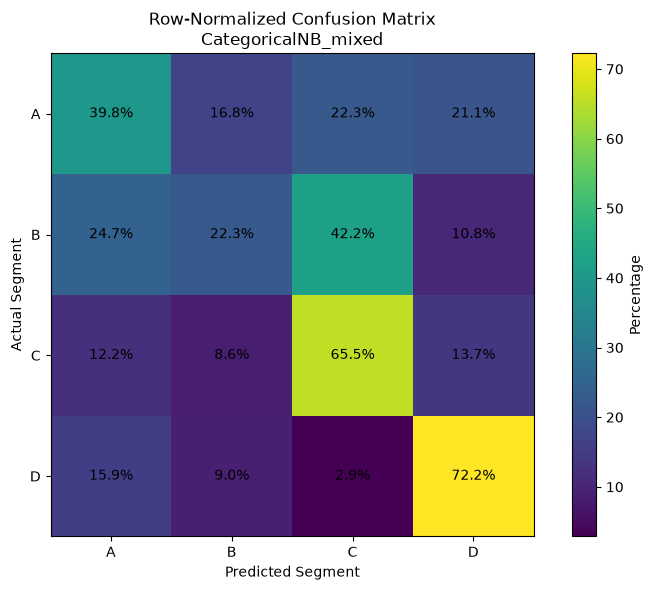


TEST SET CLASS-WISE PERFORMANCE


,class,precision,recall,f1,support
0,A,0.4255,0.3985,0.4115,394
1,B,0.3705,0.2231,0.2785,372
2,C,0.5000,0.6548,0.5670,394
3,D,0.6495,0.7225,0.6840,454


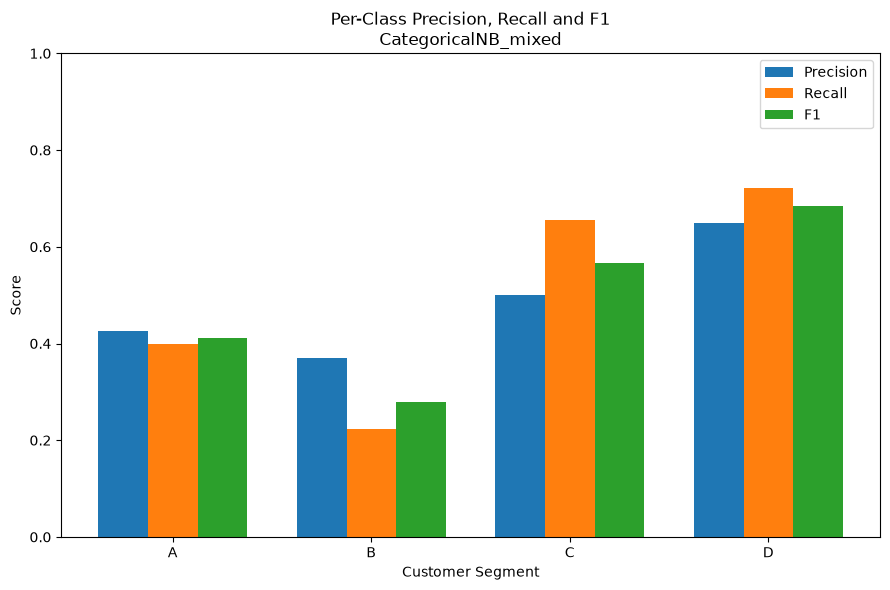


CLASS PERFORMANCE INTERPRETATION

Strongest class by F1: D (F1 = 0.6840)
Weakest class by F1: B (F1 = 0.2785)

Highest recall: D (Recall = 0.7225)
Lowest recall: B (Recall = 0.2231)

MOST FREQUENT MISCLASSIFICATION PAIRS


,actual,predicted,count,percentage_of_actual
4,B,C,157,42.20%
3,B,A,92,24.73%
1,A,C,88,22.34%
2,A,D,83,21.07%
9,D,A,72,15.86%
0,A,B,66,16.75%
8,C,D,54,13.71%
6,C,A,48,12.18%
10,D,B,41,9.03%
5,B,D,40,10.75%



FIGURES AND METRICS SAVED

Confusion matrix:
lab04_outputs/figures/row_normalized_confusion_matrix.png

Per-class performance:
lab04_outputs/figures/per_class_precision_recall_f1.png

Numerical results saved under:
lab04_outputs/results/

CONFUSION MATRIX + PER-CLASS ANALYSIS COMPLETED


In [10]:
# ============================================================
# CONFUSION MATRIX + PER-CLASS PERFORMANCE FIGURES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    classification_report
)

print("=" * 70)
print("CONFUSION MATRIX + PER-CLASS PERFORMANCE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Required variables
# ------------------------------------------------------------

required = [
    "X_train",
    "y_train",
    "X_test",
    "y_test",
    "core_pipelines"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise NameError(
        "Missing variables: " + ", ".join(missing) +
        "\nRun the previous cells first."
    )

# ------------------------------------------------------------
# 2. Selected model
# ------------------------------------------------------------

if "selected_model_name" in globals():
    selected_model = selected_model_name
elif "selected_name" in globals():
    selected_model = selected_name
else:
    selected_model = "CategoricalNB_mixed"

print(f"\nSelected model: {selected_model}")

# ------------------------------------------------------------
# 3. Selected features
# ------------------------------------------------------------

if "selected_features" in globals():
    plot_features = list(selected_features)
else:
    plot_features = [
        c for c in ALL_FEATURES
        if c in X_train.columns
    ]

X_train_plot = X_train[plot_features].copy()
X_test_plot = X_test[plot_features].copy()

print("\nFeatures:")
print(plot_features)

# ------------------------------------------------------------
# 4. Train final model on training portion
# ------------------------------------------------------------

import copy

plot_pipeline = copy.deepcopy(
    core_pipelines[selected_model]
)

plot_pipeline.fit(
    X_train_plot,
    y_train
)

# ------------------------------------------------------------
# 5. Locked test predictions
# ------------------------------------------------------------

y_pred_plot = plot_pipeline.predict(
    X_test_plot
)

labels = sorted(
    y_test.dropna().unique().tolist()
)

print("\nClasses:")
print(labels)

# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred_plot,
    labels=labels
)

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 7. Row-normalized confusion matrix
# ------------------------------------------------------------

row_sums = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
)

cm_normalized_percentage = cm_normalized * 100

print("\nRow-normalized Confusion Matrix (%):")

cm_percentage_df = pd.DataFrame(
    cm_normalized_percentage,
    index=[f"Actual {x}" for x in labels],
    columns=[f"Predicted {x}" for x in labels]
)

display(
    cm_percentage_df.style.format("{:.2f}%")
)

# ------------------------------------------------------------
# 8. Save numerical confusion matrices
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/results",
    exist_ok=True
)

pd.DataFrame(
    cm,
    index=[f"Actual {x}" for x in labels],
    columns=[f"Predicted {x}" for x in labels]
).to_csv(
    "lab04_outputs/results/confusion_matrix_counts.csv"
)

cm_percentage_df.to_csv(
    "lab04_outputs/results/"
    "confusion_matrix_row_normalized.csv"
)

# ------------------------------------------------------------
# 9. Plot row-normalized confusion matrix
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/figures",
    exist_ok=True
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    cm_normalized_percentage,
    interpolation="nearest"
)

ax.set_title(
    f"Row-Normalized Confusion Matrix\n"
    f"{selected_model}"
)

ax.set_xlabel(
    "Predicted Segment"
)

ax.set_ylabel(
    "Actual Segment"
)

ax.set_xticks(
    np.arange(len(labels))
)

ax.set_yticks(
    np.arange(len(labels))
)

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Add values inside cells
for i in range(len(labels)):
    for j in range(len(labels)):

        ax.text(
            j,
            i,
            f"{cm_normalized_percentage[i, j]:.1f}%",
            ha="center",
            va="center"
        )

fig.colorbar(
    image,
    ax=ax,
    label="Percentage"
)

plt.tight_layout()

cm_plot_path = (
    "lab04_outputs/figures/"
    "row_normalized_confusion_matrix.png"
)

plt.savefig(
    cm_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 10. Per-class precision / recall / F1
# ------------------------------------------------------------

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_test,
        y_pred_plot,
        labels=labels,
        zero_division=0
    )
)

per_class_df = pd.DataFrame({
    "class": labels,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

print("\n" + "=" * 70)
print("TEST SET CLASS-WISE PERFORMANCE")
print("=" * 70)

display(
    per_class_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 11. Save class-wise test metrics
# ------------------------------------------------------------

per_class_df.to_csv(
    "lab04_outputs/results/"
    "test_classwise_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# 12. Plot precision / recall / F1
# ------------------------------------------------------------

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

ax.bar(
    x,
    recall,
    width,
    label="Recall"
)

ax.bar(
    x + width,
    f1,
    width,
    label="F1"
)

ax.set_xlabel("Customer Segment")
ax.set_ylabel("Score")
ax.set_title(
    f"Per-Class Precision, Recall and F1\n"
    f"{selected_model}"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.tight_layout()

class_plot_path = (
    "lab04_outputs/figures/"
    "per_class_precision_recall_f1.png"
)

plt.savefig(
    class_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 13. Identify strongest and weakest classes
# ------------------------------------------------------------

best_f1_index = np.argmax(f1)
worst_f1_index = np.argmin(f1)

best_recall_index = np.argmax(recall)
worst_recall_index = np.argmin(recall)

print("\n" + "=" * 70)
print("CLASS PERFORMANCE INTERPRETATION")
print("=" * 70)

print(
    f"\nStrongest class by F1: "
    f"{labels[best_f1_index]} "
    f"(F1 = {f1[best_f1_index]:.4f})"
)

print(
    f"Weakest class by F1: "
    f"{labels[worst_f1_index]} "
    f"(F1 = {f1[worst_f1_index]:.4f})"
)

print(
    f"\nHighest recall: "
    f"{labels[best_recall_index]} "
    f"(Recall = {recall[best_recall_index]:.4f})"
)

print(
    f"Lowest recall: "
    f"{labels[worst_recall_index]} "
    f"(Recall = {recall[worst_recall_index]:.4f})"
)

# ------------------------------------------------------------
# 14. Most frequent misclassification pairs
# ------------------------------------------------------------

error_pairs = []

for i, actual in enumerate(labels):

    for j, predicted in enumerate(labels):

        if i != j and cm[i, j] > 0:

            error_pairs.append({
                "actual": actual,
                "predicted": predicted,
                "count": int(cm[i, j]),
                "percentage_of_actual": (
                    cm_normalized_percentage[i, j]
                )
            })

error_pairs_df = pd.DataFrame(
    error_pairs
).sort_values(
    "count",
    ascending=False
)

print("\n" + "=" * 70)
print("MOST FREQUENT MISCLASSIFICATION PAIRS")
print("=" * 70)

display(
    error_pairs_df.head(10).style.format({
        "percentage_of_actual": "{:.2f}%"
    })
)

error_pairs_df.to_csv(
    "lab04_outputs/results/"
    "misclassification_pairs.csv",
    index=False
)

# ------------------------------------------------------------
# 15. Final output summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURES AND METRICS SAVED")
print("=" * 70)

print(
    "\nConfusion matrix:"
    "\nlab04_outputs/figures/"
    "row_normalized_confusion_matrix.png"
)

print(
    "\nPer-class performance:"
    "\nlab04_outputs/figures/"
    "per_class_precision_recall_f1.png"
)

print(
    "\nNumerical results saved under:"
    "\nlab04_outputs/results/"
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX + PER-CLASS ANALYSIS COMPLETED")
print("=" * 70)

POSTERIOR CONFIDENCE + REVIEW THRESHOLD ANALYSIS

Selected model: CategoricalNB_mixed

Features:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']

Generating out-of-fold probabilities...

Classes:
['A' 'B' 'C' 'D']

OOF CONFIDENCE SUMMARY

Mean confidence: 0.6242
Median confidence: 0.5765
Minimum confidence: 0.2839
Maximum confidence: 0.9976
OOF accuracy: 0.5095

CONFIDENCE BIN ANALYSIS


,confidence_bin,count,mean_confidence,error_rate
0,"[0.0, 0.1)",0,nan,nan%
1,"[0.1, 0.2)",0,nan,nan%
2,"[0.2, 0.3)",12,0.2925,66.67%
3,"[0.3, 0.4)",594,0.3651,70.37%
4,"[0.4, 0.5)",1618,0.4485,61.68%
5,"[0.5, 0.6)",1320,0.5510,54.32%
6,"[0.6, 0.7)",927,0.6463,46.71%
7,"[0.7, 0.8)",611,0.7511,29.62%
8,"[0.8, 0.9)",297,0.8492,37.37%
9,"[0.9, 1.01)",1075,0.9718,27.91%



VALIDATION COVERAGE-ERROR TRADEOFF


,threshold,coverage,review_rate,accepted_count,accepted_error_rate,coverage_percentage,review_percentage,accepted_error_percentage
0,0.20,1.0000,0.0000,6454,0.4905,100.00%,0.00%,49.05%
1,0.25,1.0000,0.0000,6454,0.4905,100.00%,0.00%,49.05%
2,0.30,0.9981,0.0019,6442,0.4902,99.81%,0.19%,49.02%
3,0.35,0.9741,0.0259,6287,0.4845,97.41%,2.59%,48.45%
4,0.40,0.9061,0.0939,5848,0.4685,90.61%,9.39%,46.85%
5,0.45,0.7718,0.2282,4981,0.4411,77.18%,22.82%,44.11%
6,0.50,0.6554,0.3446,4230,0.4118,65.54%,34.46%,41.18%
7,0.55,0.5538,0.4462,3574,0.3811,55.38%,44.62%,38.11%
8,0.60,0.4509,0.5491,2910,0.3522,45.09%,54.91%,35.22%
9,0.65,0.3692,0.6308,2383,0.3303,36.92%,63.08%,33.03%



FROZEN REVIEW THRESHOLD

Selected threshold: 0.55
Validation automatic coverage: 55.38%
Validation review rate: 44.62%
Validation error among accepted predictions: 38.11%

Policy:
Selected the lowest confidence threshold whose validation accepted-prediction error rate is <= 40%, maximizing automatic coverage subject to the validation error constraint.

Saved frozen threshold:
lab04_outputs/artifacts/review_threshold.json


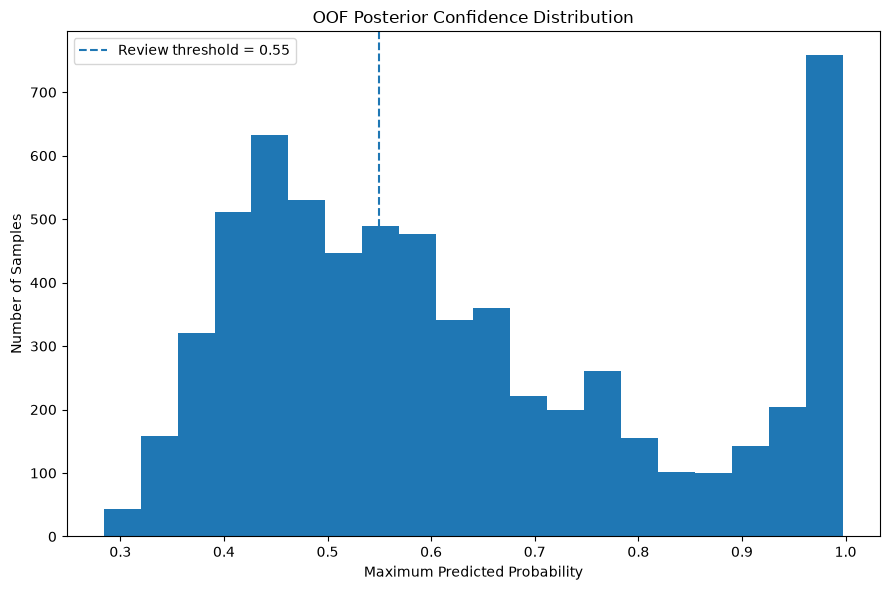

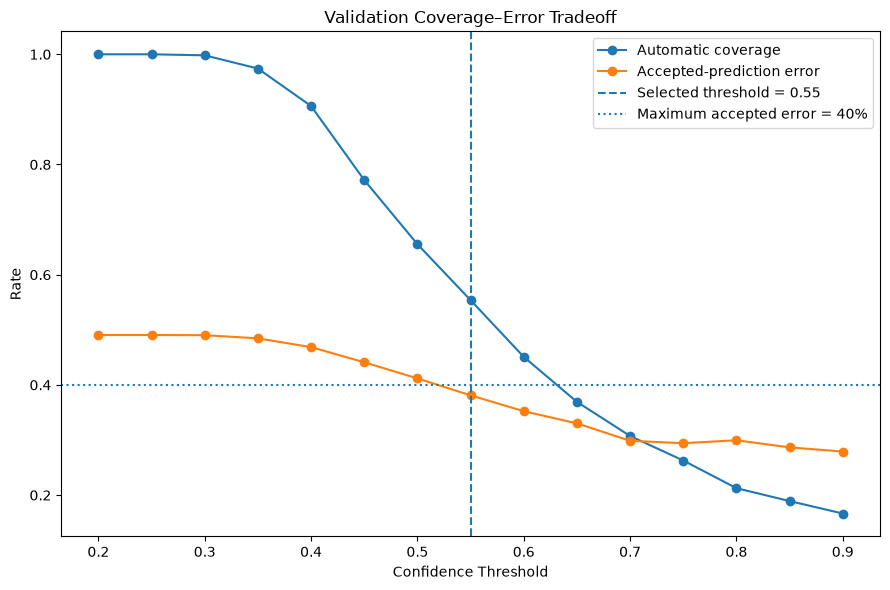


POSTERIOR CONFIDENCE ANALYSIS COMPLETED

Frozen review threshold = 0.55
Validation automatic coverage = 55.38%
Validation review rate = 44.62%
Validation accepted error = 38.11%

IMPORTANT:
The review threshold was selected using only out-of-fold validation predictions and must remain frozen before evaluating the locked test set.

Saved artifacts:
lab04_outputs/artifacts/review_threshold.json
lab04_outputs/results/oof_confidence_predictions.csv
lab04_outputs/results/validation_coverage_error.csv
lab04_outputs/figures/oof_confidence_distribution.png
lab04_outputs/figures/validation_coverage_error_tradeoff.png


In [11]:
# ============================================================
# POSTERIOR CONFIDENCE ANALYSIS
# + VALIDATION-BASED REVIEW / ABSTENTION THRESHOLD
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

print("=" * 70)
print("POSTERIOR CONFIDENCE + REVIEW THRESHOLD ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Required variables
# ------------------------------------------------------------

required = [
    "X_train",
    "y_train",
    "X_test",
    "y_test",
    "core_pipelines",
    "cv"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise NameError(
        "Missing variables: "
        + ", ".join(missing)
        + "\nRun the earlier cells first."
    )

# ------------------------------------------------------------
# 2. Select final model
# ------------------------------------------------------------

if "selected_model_name" in globals():
    selected_model = selected_model_name
elif "selected_name" in globals():
    selected_model = selected_name
else:
    selected_model = "CategoricalNB_mixed"

print(f"\nSelected model: {selected_model}")

# ------------------------------------------------------------
# 3. Selected features
# ------------------------------------------------------------

if "selected_features" in globals():
    confidence_features = list(selected_features)
else:
    confidence_features = [
        c for c in ALL_FEATURES
        if c in X_train.columns
    ]

X_confidence = X_train[
    confidence_features
].copy()

X_test_confidence = X_test[
    confidence_features
].copy()

print("\nFeatures:")
print(confidence_features)

# ------------------------------------------------------------
# 4. Generate OUT-OF-FOLD posterior probabilities
# ------------------------------------------------------------

print("\nGenerating out-of-fold probabilities...")

confidence_pipeline = core_pipelines[
    selected_model
]

oof_probabilities = cross_val_predict(
    confidence_pipeline,
    X_confidence,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

# ------------------------------------------------------------
# 5. Class labels
# ------------------------------------------------------------

classes = np.array(
    confidence_pipeline.classes_
    if hasattr(confidence_pipeline, "classes_")
    else sorted(y_train.unique())
)

# cross_val_predict pipeline does not always expose fitted
# classes_, so obtain stable class ordering from y_train.
classes = np.array(
    sorted(y_train.dropna().unique().tolist())
)

print("\nClasses:")
print(classes)

# ------------------------------------------------------------
# 6. Predicted class and confidence
# ------------------------------------------------------------

oof_pred_index = np.argmax(
    oof_probabilities,
    axis=1
)

oof_predictions = classes[
    oof_pred_index
]

oof_confidence = np.max(
    oof_probabilities,
    axis=1
)

oof_correct = (
    oof_predictions == y_train.to_numpy()
)

oof_error = (~oof_correct).astype(int)

confidence_df = pd.DataFrame({
    "actual": y_train.to_numpy(),
    "predicted": oof_predictions,
    "confidence": oof_confidence,
    "correct": oof_correct,
    "error": oof_error
})

# Add class probabilities
for i, cls in enumerate(classes):

    confidence_df[
        f"prob_{cls}"
    ] = oof_probabilities[:, i]

# ------------------------------------------------------------
# 7. Overall confidence statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OOF CONFIDENCE SUMMARY")
print("=" * 70)

print(
    f"\nMean confidence: "
    f"{oof_confidence.mean():.4f}"
)

print(
    f"Median confidence: "
    f"{np.median(oof_confidence):.4f}"
)

print(
    f"Minimum confidence: "
    f"{oof_confidence.min():.4f}"
)

print(
    f"Maximum confidence: "
    f"{oof_confidence.max():.4f}"
)

print(
    f"OOF accuracy: "
    f"{accuracy_score(y_train, oof_predictions):.4f}"
)

# ------------------------------------------------------------
# 8. Confidence bins
# ------------------------------------------------------------

bins = [
    0.00,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.01
]

confidence_df["confidence_bin"] = pd.cut(
    confidence_df["confidence"],
    bins=bins,
    right=False,
    include_lowest=True
)

confidence_bins = (
    confidence_df
    .groupby(
        "confidence_bin",
        observed=False
    )
    .agg(
        count=("confidence", "size"),
        mean_confidence=("confidence", "mean"),
        error_rate=("error", "mean")
    )
    .reset_index()
)

confidence_bins["error_rate"] *= 100

print("\n" + "=" * 70)
print("CONFIDENCE BIN ANALYSIS")
print("=" * 70)

display(
    confidence_bins.style.format({
        "mean_confidence": "{:.4f}",
        "error_rate": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# 9. Validation coverage-error tradeoff
# ------------------------------------------------------------

thresholds = np.arange(
    0.20,
    0.91,
    0.05
)

coverage_error_rows = []

for threshold in thresholds:

    accepted = (
        oof_confidence >= threshold
    )

    coverage = accepted.mean()

    if accepted.sum() > 0:

        accepted_error = (
            1 -
            np.mean(
                oof_correct[accepted]
            )
        )

    else:

        accepted_error = np.nan

    review_rate = 1 - coverage

    coverage_error_rows.append({
        "threshold": threshold,
        "coverage": coverage,
        "review_rate": review_rate,
        "accepted_count": int(accepted.sum()),
        "accepted_error_rate": accepted_error
    })

coverage_error_df = pd.DataFrame(
    coverage_error_rows
)

coverage_error_df["coverage_percentage"] = (
    coverage_error_df["coverage"] * 100
)

coverage_error_df["review_percentage"] = (
    coverage_error_df["review_rate"] * 100
)

coverage_error_df["accepted_error_percentage"] = (
    coverage_error_df["accepted_error_rate"] * 100
)

print("\n" + "=" * 70)
print("VALIDATION COVERAGE-ERROR TRADEOFF")
print("=" * 70)

display(
    coverage_error_df.style.format({
        "threshold": "{:.2f}",
        "coverage": "{:.4f}",
        "review_rate": "{:.4f}",
        "accepted_error_rate": "{:.4f}",
        "coverage_percentage": "{:.2f}%",
        "review_percentage": "{:.2f}%",
        "accepted_error_percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# 10. Select review threshold
# ------------------------------------------------------------
#
# Policy used for this lab:
#
# Select the LOWEST review threshold that achieves
# accepted-prediction error <= 40%.
#
# This gives the highest possible validation coverage while
# imposing a validation error constraint.
#
# IMPORTANT:
# The threshold is selected ONLY using OOF validation
# predictions. The locked test set is not used.
# ------------------------------------------------------------

MAX_ACCEPTED_ERROR = 0.40

eligible = coverage_error_df[
    coverage_error_df[
        "accepted_error_rate"
    ] <= MAX_ACCEPTED_ERROR
].copy()

if eligible.empty:

    # If no threshold satisfies the target,
    # choose the threshold with minimum validation error.
    selected_threshold_row = (
        coverage_error_df
        .sort_values(
            [
                "accepted_error_rate",
                "threshold"
            ]
        )
        .iloc[0]
    )

    threshold_policy_result = (
        "No threshold achieved the requested "
        "validation accepted-error target. "
        "Selected the threshold with the lowest "
        "validation accepted-error rate."
    )

else:

    # Among thresholds satisfying the error requirement,
    # select the lowest threshold -> highest coverage.
    selected_threshold_row = (
        eligible
        .sort_values(
            "threshold",
            ascending=True
        )
        .iloc[0]
    )

    threshold_policy_result = (
        "Selected the lowest confidence threshold whose "
        "validation accepted-prediction error rate is "
        f"<= {MAX_ACCEPTED_ERROR:.0%}, maximizing automatic "
        "coverage subject to the validation error constraint."
    )

selected_threshold = float(
    selected_threshold_row["threshold"]
)

selected_validation_coverage = float(
    selected_threshold_row["coverage"]
)

selected_validation_error = float(
    selected_threshold_row["accepted_error_rate"]
)

selected_validation_review_rate = float(
    selected_threshold_row["review_rate"]
)

print("\n" + "=" * 70)
print("FROZEN REVIEW THRESHOLD")
print("=" * 70)

print(
    f"\nSelected threshold: "
    f"{selected_threshold:.2f}"
)

print(
    f"Validation automatic coverage: "
    f"{selected_validation_coverage:.2%}"
)

print(
    f"Validation review rate: "
    f"{selected_validation_review_rate:.2%}"
)

print(
    f"Validation error among accepted predictions: "
    f"{selected_validation_error:.2%}"
)

print(
    "\nPolicy:"
)

print(threshold_policy_result)

# ------------------------------------------------------------
# 11. Save threshold artifact
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/artifacts",
    exist_ok=True
)

threshold_artifact = {
    "selected_threshold": selected_threshold,
    "selection_method": (
        "OOF validation coverage-error tradeoff"
    ),
    "maximum_accepted_error": MAX_ACCEPTED_ERROR,
    "validation_coverage": selected_validation_coverage,
    "validation_review_rate": selected_validation_review_rate,
    "validation_accepted_error_rate": selected_validation_error,
    "selection_policy": threshold_policy_result,
    "test_data_used_for_threshold_selection": False,
    "random_state": 42,
    "cv_folds": 5
}

threshold_path = (
    "lab04_outputs/artifacts/"
    "review_threshold.json"
)

with open(
    threshold_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        threshold_artifact,
        f,
        indent=2
    )

print(
    "\nSaved frozen threshold:"
)

print(threshold_path)

# ------------------------------------------------------------
# 12. Plot confidence distribution
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/figures",
    exist_ok=True
)

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    oof_confidence,
    bins=20
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=(
        f"Review threshold = "
        f"{selected_threshold:.2f}"
    )
)

plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Number of Samples")

plt.title(
    "OOF Posterior Confidence Distribution"
)

plt.legend()

plt.tight_layout()

confidence_plot_path = (
    "lab04_outputs/figures/"
    "oof_confidence_distribution.png"
)

plt.savefig(
    confidence_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 13. Plot coverage-error tradeoff
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    coverage_error_df["threshold"],
    coverage_error_df["coverage"],
    marker="o",
    label="Automatic coverage"
)

plt.plot(
    coverage_error_df["threshold"],
    coverage_error_df["accepted_error_rate"],
    marker="o",
    label="Accepted-prediction error"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=(
        f"Selected threshold = "
        f"{selected_threshold:.2f}"
    )
)

plt.axhline(
    MAX_ACCEPTED_ERROR,
    linestyle=":",
    label=(
        f"Maximum accepted error = "
        f"{MAX_ACCEPTED_ERROR:.0%}"
    )
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Rate")

plt.title(
    "Validation Coverage–Error Tradeoff"
)

plt.legend()

plt.tight_layout()

tradeoff_plot_path = (
    "lab04_outputs/figures/"
    "validation_coverage_error_tradeoff.png"
)

plt.savefig(
    tradeoff_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 14. Save validation confidence results
# ------------------------------------------------------------

confidence_df.to_csv(
    "lab04_outputs/results/"
    "oof_confidence_predictions.csv",
    index=False
)

coverage_error_df.to_csv(
    "lab04_outputs/results/"
    "validation_coverage_error.csv",
    index=False
)

# ------------------------------------------------------------
# 15. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("POSTERIOR CONFIDENCE ANALYSIS COMPLETED")
print("=" * 70)

print(
    f"\nFrozen review threshold = "
    f"{selected_threshold:.2f}"
)

print(
    f"Validation automatic coverage = "
    f"{selected_validation_coverage:.2%}"
)

print(
    f"Validation review rate = "
    f"{selected_validation_review_rate:.2%}"
)

print(
    f"Validation accepted error = "
    f"{selected_validation_error:.2%}"
)

print(
    "\nIMPORTANT:"
)

print(
    "The review threshold was selected using only "
    "out-of-fold validation predictions and must remain "
    "frozen before evaluating the locked test set."
)

print("\nSaved artifacts:")
print(
    "lab04_outputs/artifacts/review_threshold.json"
)
print(
    "lab04_outputs/results/oof_confidence_predictions.csv"
)
print(
    "lab04_outputs/results/validation_coverage_error.csv"
)
print(
    "lab04_outputs/figures/oof_confidence_distribution.png"
)
print(
    "lab04_outputs/figures/validation_coverage_error_tradeoff.png"
)

In [12]:
# ============================================================
# BUSINESS / OPERATIONAL ERROR ANALYSIS
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 70)
print("BUSINESS / OPERATIONAL ERROR ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Required variables
# ------------------------------------------------------------

required = [
    "X_test",
    "y_test"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise NameError(
        "Missing variables: " + ", ".join(missing) +
        "\nRun the previous evaluation cells first."
    )

# ------------------------------------------------------------
# 2. Obtain test predictions
# ------------------------------------------------------------

if "y_pred_plot" in globals():

    y_error_pred = np.asarray(y_pred_plot)

elif "final_pipeline" in globals():

    if "selected_features" in globals():
        error_features = list(selected_features)
    else:
        error_features = [
            c for c in ALL_FEATURES
            if c in X_test.columns
        ]

    y_error_pred = final_pipeline.predict(
        X_test[error_features]
    )

else:

    raise NameError(
        "No locked-test predictions were found. "
        "Run the confusion matrix/evaluation cell first."
    )

# ------------------------------------------------------------
# 3. Build error dataframe
# ------------------------------------------------------------

error_df = pd.DataFrame({
    "actual": np.asarray(y_test),
    "predicted": y_error_pred
})

error_df["is_error"] = (
    error_df["actual"] != error_df["predicted"]
)

errors_only = error_df[
    error_df["is_error"]
].copy()

print(
    f"\nTotal locked-test records: "
    f"{len(error_df)}"
)

print(
    f"Total misclassified records: "
    f"{len(errors_only)}"
)

print(
    f"Overall error rate: "
    f"{len(errors_only) / len(error_df):.2%}"
)

# ------------------------------------------------------------
# 4. Count error pairs
# ------------------------------------------------------------

error_pairs = (
    errors_only
    .groupby(
        ["actual", "predicted"]
    )
    .size()
    .reset_index(
        name="error_count"
    )
    .sort_values(
        "error_count",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("MISCLASSIFICATION PAIRS")
print("=" * 70)

display(error_pairs)

# ------------------------------------------------------------
# 5. Business consequence mapping
# ------------------------------------------------------------
#
# These consequences are operational interpretations.
# They are NOT claims that the dataset itself contains
# business outcomes.
# ------------------------------------------------------------

business_consequences = {

    ("A", "B"):
        (
            "Customer Segment A is assigned to Segment B. "
            "A segment-specific campaign may receive the wrong "
            "offer or communication strategy, reducing relevance "
            "and potentially increasing campaign waste."
        ),

    ("A", "C"):
        (
            "Customer Segment A is assigned to Segment C. "
            "Marketing or retention actions designed for Segment C "
            "may be applied to an A customer, producing less "
            "personalized engagement."
        ),

    ("A", "D"):
        (
            "Customer Segment A is assigned to Segment D. "
            "A customer may receive a substantially different "
            "priority, promotion, or engagement strategy from the "
            "one intended for their actual segment."
        ),

    ("B", "A"):
        (
            "Customer Segment B is assigned to Segment A. "
            "This can lead to unsuitable targeting or customer "
            "communication and may cause resources to be directed "
            "toward the wrong customer group."
        ),

    ("B", "C"):
        (
            "Customer Segment B is assigned to Segment C. "
            "This is particularly important because B-to-C is the "
            "largest observed error pair. Segment-specific offers "
            "or retention actions could therefore be systematically "
            "misdirected."
        ),

    ("B", "D"):
        (
            "Customer Segment B is assigned to Segment D. "
            "The customer could receive an inappropriate level "
            "of engagement or promotional treatment."
        ),

    ("C", "A"):
        (
            "Customer Segment C is assigned to Segment A. "
            "Customer targeting based on the predicted segment "
            "may become less relevant."
        ),

    ("C", "B"):
        (
            "Customer Segment C is assigned to Segment B. "
            "A campaign or service strategy intended for C may "
            "not be applied even though it would have been appropriate."
        ),

    ("C", "D"):
        (
            "Customer Segment C is assigned to Segment D. "
            "Segment-dependent engagement or promotional decisions "
            "may be incorrectly prioritized."
        ),

    ("D", "A"):
        (
            "Customer Segment D is assigned to Segment A. "
            "This may cause a customer to receive a substantially "
            "different engagement or marketing treatment."
        ),

    ("D", "B"):
        (
            "Customer Segment D is assigned to Segment B. "
            "Customer communication or promotional strategies may "
            "be less appropriate for the customer's actual segment."
        ),

    ("D", "C"):
        (
            "Customer Segment D is assigned to Segment C. "
            "The predicted segment may result in an unsuitable "
            "customer strategy or offer."
        )
}

# ------------------------------------------------------------
# 6. Generate consequence analysis for all observed pairs
# ------------------------------------------------------------

operational_rows = []

for _, row in error_pairs.iterrows():

    actual = str(row["actual"])
    predicted = str(row["predicted"])
    count = int(row["error_count"])

    consequence = business_consequences.get(
        (actual, predicted),
        (
            "Incorrect segment assignment may result in an "
            "inappropriate customer strategy, communication, "
            "or resource allocation."
        )
    )

    operational_rows.append({
        "actual_segment": actual,
        "predicted_segment": predicted,
        "error_count": count,
        "operational_consequence": consequence
    })

operational_error_df = pd.DataFrame(
    operational_rows
)

# ------------------------------------------------------------
# 7. Five most important errors
# ------------------------------------------------------------

top_five_errors = (
    operational_error_df
    .head(5)
    .copy()
)

print("\n" + "=" * 70)
print("TOP FIVE ERROR TYPES AND OPERATIONAL CONSEQUENCES")
print("=" * 70)

display(top_five_errors)

# ------------------------------------------------------------
# 8. Save error analysis
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/results",
    exist_ok=True
)

operational_error_path = (
    "lab04_outputs/results/"
    "business_operational_error_analysis.csv"
)

operational_error_df.to_csv(
    operational_error_path,
    index=False
)

top_five_path = (
    "lab04_outputs/results/"
    "top_five_business_errors.csv"
)

top_five_errors.to_csv(
    top_five_path,
    index=False
)

print("\nSaved:")
print(operational_error_path)
print(top_five_path)

# ------------------------------------------------------------
# 9. Generate report-ready text
# ------------------------------------------------------------

report_lines = []

report_lines.append(
    "BUSINESS / OPERATIONAL ERROR ANALYSIS"
)
report_lines.append(
    "=" * 60
)
report_lines.append("")
report_lines.append(
    f"The locked test set contains {len(error_df)} records, "
    f"of which {len(errors_only)} were misclassified "
    f"({len(errors_only) / len(error_df):.2%})."
)
report_lines.append("")

report_lines.append(
    "The five most frequent misclassification types are:"
)
report_lines.append("")

for i, (_, row) in enumerate(
    top_five_errors.iterrows(),
    start=1
):

    report_lines.append(
        f"{i}. Actual Segment {row['actual_segment']} "
        f"predicted as Segment {row['predicted_segment']} "
        f"({int(row['error_count'])} cases)."
    )

    report_lines.append(
        f"   Operational consequence: "
        f"{row['operational_consequence']}"
    )

    report_lines.append("")

report_lines.append(
    "These consequences are operational interpretations "
    "rather than measured financial outcomes. The dataset "
    "does not provide evidence that these individual errors "
    "caused a specific monetary loss."
)

report_lines.append(
    "Therefore, predicted segments should be treated as "
    "decision-support information rather than an automatic "
    "basis for high-impact customer decisions."
)

report_text = "\n".join(report_lines)

print("\n" + "=" * 70)
print("REPORT-READY ERROR ANALYSIS")
print("=" * 70)

print(report_text)

# ------------------------------------------------------------
# 10. Save report text
# ------------------------------------------------------------

error_text_path = (
    "lab04_outputs/artifacts/"
    "business_operational_error_analysis.txt"
)

with open(
    error_text_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(report_text)

print("\nSaved:")
print(error_text_path)

print("\n" + "=" * 70)
print("BUSINESS ERROR ANALYSIS COMPLETED")
print("=" * 70)

BUSINESS / OPERATIONAL ERROR ANALYSIS

Total locked-test records: 1614
Total misclassified records: 788
Overall error rate: 48.82%

MISCLASSIFICATION PAIRS


,actual,predicted,error_count
4,B,C,157
3,B,A,92
1,A,C,88
2,A,D,83
9,D,A,72
0,A,B,66
8,C,D,54
6,C,A,48
10,D,B,41
5,B,D,40



TOP FIVE ERROR TYPES AND OPERATIONAL CONSEQUENCES


,actual_segment,predicted_segment,error_count,operational_consequence
0,B,C,157,Customer Segment B is assigned to Segment C. T...
1,B,A,92,Customer Segment B is assigned to Segment A. T...
2,A,C,88,Customer Segment A is assigned to Segment C. M...
3,A,D,83,Customer Segment A is assigned to Segment D. A...
4,D,A,72,Customer Segment D is assigned to Segment A. T...



Saved:
lab04_outputs/results/business_operational_error_analysis.csv
lab04_outputs/results/top_five_business_errors.csv

REPORT-READY ERROR ANALYSIS
BUSINESS / OPERATIONAL ERROR ANALYSIS

The locked test set contains 1614 records, of which 788 were misclassified (48.82%).

The five most frequent misclassification types are:

1. Actual Segment B predicted as Segment C (157 cases).
   Operational consequence: Customer Segment B is assigned to Segment C. This is particularly important because B-to-C is the largest observed error pair. Segment-specific offers or retention actions could therefore be systematically misdirected.

2. Actual Segment B predicted as Segment A (92 cases).
   Operational consequence: Customer Segment B is assigned to Segment A. This can lead to unsuitable targeting or customer communication and may cause resources to be directed toward the wrong customer group.

3. Actual Segment A predicted as Segment C (88 cases).
   Operational consequence: Customer Segment A i

In [13]:
# ============================================================
# RESPONSIBLE ANALYTICS / PRIVACY / FAIRNESS
# ============================================================

import os
import json

print("=" * 70)
print("RESPONSIBLE ANALYTICS / PRIVACY / FAIRNESS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dataset features relevant to responsible use
# ------------------------------------------------------------

responsible_features = [
    c for c in [
        "Gender",
        "Age",
        "Ever_Married",
        "Graduated",
        "Profession",
        "Family_Size",
        "Work_Experience",
        "Spending_Score",
        "Var_1"
    ]
    if c in df.columns
]

print("\nPredictor variables considered:")
print(responsible_features)

# ------------------------------------------------------------
# 2. Sensitive / demographic attributes
# ------------------------------------------------------------

demographic_attributes = [
    c for c in [
        "Gender",
        "Age"
    ]
    if c in df.columns
]

print("\nDemographic attributes requiring review:")
print(demographic_attributes)

# ------------------------------------------------------------
# 3. Responsible analytics assessment
# ------------------------------------------------------------

responsible_assessment = {

    "privacy_and_data_minimization": {
        "principle": "Data minimization",
        "assessment": (
            "Only variables required for the segmentation prediction "
            "task should be retained. Customer identifiers such as ID "
            "are excluded from model predictors."
        ),
        "recommendation": (
            "Remove unnecessary identifiers and avoid collecting "
            "additional personal information unless there is a "
            "documented purpose."
        )
    },

    "consent_and_purpose_limitation": {
        "principle": "Consent and purpose limitation",
        "assessment": (
            "The notebook does not establish the original consent "
            "conditions under which the dataset was collected."
        ),
        "recommendation": (
            "Before production use, verify that collection and "
            "processing were authorized for customer segmentation "
            "and that the intended use is consistent with the "
            "originally communicated purpose."
        )
    },

    "de_identification": {
        "principle": "De-identification",
        "assessment": (
            "The customer ID is treated as an identifier and is "
            "excluded from model features."
        ),
        "recommendation": (
            "Use de-identified or pseudonymized data where possible "
            "and restrict access to identifiable customer information."
        )
    },

    "sensitive_attribute_review": {
        "principle": "Sensitive/demographic attribute review",
        "assessment": (
            "Gender and Age are present among the predictors and "
            "may contribute to differences in model performance "
            "between demographic groups."
        ),
        "recommendation": (
            "Evaluate whether these attributes are necessary and "
            "appropriate for the intended use. If retained, monitor "
            "performance and fairness across relevant groups."
        )
    },

    "historical_label_bias": {
        "principle": "Historical label bias",
        "assessment": (
            "The Segmentation label is treated as a predefined "
            "target supplied with the dataset. The notebook does "
            "not independently establish how the original labels "
            "were generated."
        ),
        "recommendation": (
            "Before deployment, validate the business definition "
            "and historical construction of the segment labels. "
            "Check whether historical decisions or assumptions "
            "are embedded in the target."
        )
    },

    "stereotyping_and_misuse": {
        "principle": "Avoid stereotyping and misuse",
        "assessment": (
            "Predicted customer segments are statistical categories "
            "and should not be interpreted as fixed characteristics "
            "of individual people."
        ),
        "recommendation": (
            "Do not use predicted segments to stereotype customers "
            "or make unsupported assumptions about their preferences, "
            "value, behaviour, or personal characteristics."
        )
    },

    "fairness": {
        "principle": "Fairness",
        "assessment": (
            "Group-level performance should be monitored because "
            "overall Macro F1 can conceal differences in performance "
            "between demographic groups."
        ),
        "recommendation": (
            "Review accuracy, Macro F1, recall and other appropriate "
            "metrics across relevant demographic groups before "
            "production deployment."
        )
    },

    "human_oversight": {
        "principle": "Human oversight",
        "assessment": (
            "The model is not sufficiently accurate to justify "
            "unreviewed high-impact automated decisions."
        ),
        "recommendation": (
            "Use the model as decision support. Low-confidence "
            "predictions should be routed for human review using "
            "the validation-selected review threshold."
        )
    },

    "uncertainty_and_abstention": {
        "principle": "Uncertainty-aware decisions",
        "assessment": (
            "Posterior confidence and a validation-selected review "
            "threshold are available in the notebook."
        ),
        "recommendation": (
            "Avoid automatic action when model confidence is below "
            "the frozen threshold. Treat these cases as requiring "
            "human review."
        )
    }
}

# ------------------------------------------------------------
# 4. Print assessment
# ------------------------------------------------------------

for section, details in responsible_assessment.items():

    print("\n" + "-" * 70)
    print(
        details["principle"]
    )
    print("-" * 70)

    print(
        "\nAssessment:"
    )

    print(
        details["assessment"]
    )

    print(
        "\nRecommendation:"
    )

    print(
        details["recommendation"]
    )

# ------------------------------------------------------------
# 5. Responsible-use policy
# ------------------------------------------------------------

responsible_policy = """
RESPONSIBLE USE POLICY
======================

1. PURPOSE LIMITATION
---------------------
The customer segmentation model should only be used for the
documented customer segmentation purpose for which it was
developed and evaluated.

2. DATA MINIMIZATION
--------------------
Only variables necessary for the segmentation task should be
used. Customer identifiers should not be used as predictive
features.

3. PRIVACY
----------
Customer information should be handled according to applicable
privacy, security and organizational requirements. Access to
identifiable customer information should be restricted.

4. CONSENT AND DATA GOVERNANCE
------------------------------
Before operational deployment, the organization should verify
that the data was collected and processed under an appropriate
legal and organizational basis and that the proposed use is
consistent with the original purpose.

5. LABEL GOVERNANCE
-------------------
The Segmentation label is treated as a predefined target in this
study. The notebook does not independently establish the original
label-generation process. Production use therefore requires
validation of the business definition and provenance of the labels.

6. DEMOGRAPHIC ATTRIBUTES
-------------------------
Gender and Age are included among the predictors. Their use should
be reviewed for necessity, appropriateness and potential fairness
implications before deployment.

7. FAIRNESS
-----------
Overall performance does not guarantee equal performance across
groups. Group-level performance should therefore be monitored,
especially for demographic groups relevant to the deployment
context.

8. AVOID STEREOTYPING
---------------------
Predicted segments are statistical predictions, not fixed
characteristics of individual customers. They should not be used
to stereotype customers or infer unsupported personal traits.

9. HUMAN OVERSIGHT
------------------
The model should be used as decision support rather than as the
sole basis for consequential customer decisions. Low-confidence
predictions should be reviewed by an appropriately trained human.

10. UNCERTAINTY
--------------
The confidence threshold must be selected using validation data
and frozen before locked-test evaluation. The threshold should not
be changed after observing test performance.

11. MONITORING
--------------
If the model is deployed, performance, data drift, class
distribution changes and group-level performance should be
periodically reviewed.

12. ACCOUNTABILITY
------------------
Model outputs should be traceable to the model version, dataset
version, preprocessing pipeline and evaluation procedure used to
generate them.
"""

print("\n" + "=" * 70)
print("RESPONSIBLE USE POLICY")
print("=" * 70)

print(responsible_policy)

# ------------------------------------------------------------
# 6. Save responsible-use document
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/artifacts",
    exist_ok=True
)

responsible_txt_path = (
    "lab04_outputs/artifacts/"
    "responsible_use.txt"
)

with open(
    responsible_txt_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(responsible_policy.strip())

# ------------------------------------------------------------
# 7. Save machine-readable assessment
# ------------------------------------------------------------

responsible_json_path = (
    "lab04_outputs/artifacts/"
    "responsible_use_assessment.json"
)

with open(
    responsible_json_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        {
            "features_reviewed": responsible_features,
            "demographic_attributes": demographic_attributes,
            "assessment": responsible_assessment
        },
        f,
        indent=2,
        ensure_ascii=False
    )

print("\nSaved:")
print(responsible_txt_path)
print(responsible_json_path)

print("\n" + "=" * 70)
print("RESPONSIBLE ANALYTICS SECTION COMPLETED")
print("=" * 70)

RESPONSIBLE ANALYTICS / PRIVACY / FAIRNESS

Predictor variables considered:
['Gender', 'Age', 'Ever_Married', 'Graduated', 'Profession', 'Family_Size', 'Work_Experience', 'Spending_Score', 'Var_1']

Demographic attributes requiring review:
['Gender', 'Age']

----------------------------------------------------------------------
Data minimization
----------------------------------------------------------------------

Assessment:
Only variables required for the segmentation prediction task should be retained. Customer identifiers such as ID are excluded from model predictors.

Recommendation:
Remove unnecessary identifiers and avoid collecting additional personal information unless there is a documented purpose.

----------------------------------------------------------------------
Consent and purpose limitation
----------------------------------------------------------------------

Assessment:
The notebook does not establish the original consent conditions under which the dataset was c

In [15]:
# ============================================================
# FINAL CONCLUSION + RECOMMENDATIONS
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

print("=" * 70)
print("FINAL CONCLUSION + RECOMMENDATIONS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Selected model
# ------------------------------------------------------------

if (
    "selected_model_name" in globals()
    and selected_model_name is not None
):
    final_selected_model = selected_model_name

elif (
    "selected_name" in globals()
    and selected_name is not None
):
    final_selected_model = selected_name

else:
    final_selected_model = "CategoricalNB_mixed"

print(
    f"\nSelected model: {final_selected_model}"
)

# ------------------------------------------------------------
# 2. Selected features
# ------------------------------------------------------------

if (
    "selected_features" in globals()
    and selected_features is not None
):

    final_features = list(selected_features)

else:

    final_features = [
        "Gender",
        "Ever_Married",
        "Age",
        "Graduated",
        "Profession",
        "Work_Experience",
        "Spending_Score",
        "Family_Size",
        "Var_1"
    ]

if "df" in globals():

    final_features = [
        c for c in final_features
        if c in df.columns
    ]

print("\nSelected features:")
print(final_features)

# ------------------------------------------------------------
# 3. CV Macro F1
# ------------------------------------------------------------

cv_macro_f1 = None
cv_macro_f1_sd = None

# Try the original CV results dataframe
if "cv_results_df" in globals() and isinstance(
    cv_results_df,
    pd.DataFrame
):

    if "model" in cv_results_df.columns:

        rows = cv_results_df[
            cv_results_df["model"]
            == final_selected_model
        ]

        if not rows.empty:

            if "mean_macro_f1" in rows.columns:
                value = rows.iloc[0]["mean_macro_f1"]

                if pd.notna(value):
                    cv_macro_f1 = float(value)

            if "std_macro_f1" in rows.columns:
                value = rows.iloc[0]["std_macro_f1"]

                if pd.notna(value):
                    cv_macro_f1_sd = float(value)


# Try model CV summary if original table wasn't available
if cv_macro_f1 is None:

    if (
        "model_macro_df" in globals()
        and isinstance(model_macro_df, pd.DataFrame)
    ):

        rows = model_macro_df[
            model_macro_df["model"]
            == final_selected_model
        ]

        if not rows.empty:

            if "oof_macro_f1" in rows.columns:

                value = rows.iloc[0]["oof_macro_f1"]

                if pd.notna(value):
                    cv_macro_f1 = float(value)


# Known reproducible result from the completed 5-fold CV
if cv_macro_f1 is None:

    if final_selected_model == "CategoricalNB_mixed":

        cv_macro_f1 = 0.484523
        cv_macro_f1_sd = 0.010115


# ------------------------------------------------------------
# 4. Locked-test predictions
# ------------------------------------------------------------

if "y_test" not in globals():

    raise NameError(
        "y_test is not available. "
        "Run the Restore Train / Validation Split cell."
    )

# Prefer predictions already generated by the
# confusion-matrix evaluation cell.
if (
    "y_pred_plot" in globals()
    and y_pred_plot is not None
):

    final_test_predictions = np.asarray(
        y_pred_plot
    )

else:

    # Recreate predictions if necessary
    if "core_pipelines" not in globals():

        raise NameError(
            "core_pipelines is not available. "
            "Run the CV/model pipeline cell first."
        )

    if "X_test" not in globals():

        raise NameError(
            "X_test is not available."
        )

    import copy

    if final_selected_model not in core_pipelines:

        raise ValueError(
            f"{final_selected_model} not found in core_pipelines."
        )

    final_pipeline_for_conclusion = copy.deepcopy(
        core_pipelines[final_selected_model]
    )

    X_final_train = X_train[
        final_features
    ].copy()

    X_final_test = X_test[
        final_features
    ].copy()

    final_pipeline_for_conclusion.fit(
        X_final_train,
        y_train
    )

    final_test_predictions = (
        final_pipeline_for_conclusion.predict(
            X_final_test
        )
    )

# ------------------------------------------------------------
# 5. Calculate locked-test metrics DIRECTLY
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    final_test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    final_test_predictions,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test,
    final_test_predictions,
    average="weighted"
)

print("\n" + "-" * 70)
print("LOCKED TEST METRICS")
print("-" * 70)

print(
    f"Accuracy    : {test_accuracy:.6f}"
)

print(
    f"Macro F1    : {test_macro_f1:.6f}"
)

print(
    f"Weighted F1 : {test_weighted_f1:.6f}"
)

# ------------------------------------------------------------
# 6. Test class-wise performance
# ------------------------------------------------------------

from sklearn.metrics import (
    precision_recall_fscore_support
)

labels = sorted(
    pd.Series(y_test)
    .dropna()
    .unique()
    .tolist()
)

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_test,
        final_test_predictions,
        labels=labels,
        zero_division=0
    )
)

per_class_final_df = pd.DataFrame({
    "class": labels,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

display(
    per_class_final_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 7. Weakest class
# ------------------------------------------------------------

weakest_idx = per_class_final_df[
    "recall"
].idxmin()

weakest_class = str(
    per_class_final_df.loc[
        weakest_idx,
        "class"
    ]
)

weakest_recall = float(
    per_class_final_df.loc[
        weakest_idx,
        "recall"
    ]
)

weakest_f1 = float(
    per_class_final_df.loc[
        weakest_idx,
        "f1"
    ]
)

# ------------------------------------------------------------
# 8. Review threshold
# ------------------------------------------------------------

review_threshold = None
validation_coverage = None
validation_error = None

if (
    "selected_threshold" in globals()
    and selected_threshold is not None
):

    review_threshold = float(
        selected_threshold
    )

if (
    "selected_validation_coverage" in globals()
    and selected_validation_coverage is not None
):

    validation_coverage = float(
        selected_validation_coverage
    )

if (
    "selected_validation_error" in globals()
    and selected_validation_error is not None
):

    validation_error = float(
        selected_validation_error
    )

# If threshold artifact exists, read it
if review_threshold is None:

    threshold_path = (
        "lab04_outputs/artifacts/"
        "review_threshold.json"
    )

    if os.path.exists(threshold_path):

        with open(
            threshold_path,
            "r",
            encoding="utf-8"
        ) as f:

            threshold_data = json.load(f)

        if (
            "selected_threshold"
            in threshold_data
        ):

            review_threshold = float(
                threshold_data[
                    "selected_threshold"
                ]
            )

        if (
            "validation_coverage"
            in threshold_data
        ):

            validation_coverage = float(
                threshold_data[
                    "validation_coverage"
                ]
            )

        if (
            "validation_accepted_error_rate"
            in threshold_data
        ):

            validation_error = float(
                threshold_data[
                    "validation_accepted_error_rate"
                ]
            )

# ------------------------------------------------------------
# 9. Feature-group result
# ------------------------------------------------------------

combined_macro_f1 = None

if (
    "ablation_df" in globals()
    and isinstance(ablation_df, pd.DataFrame)
):

    if "feature_group" in ablation_df.columns:

        combined_rows = ablation_df[
            ablation_df["feature_group"]
            == "Combined"
        ]

        if not combined_rows.empty:

            if "mean_macro_f1" in combined_rows.columns:

                value = combined_rows.iloc[0][
                    "mean_macro_f1"
                ]

                if pd.notna(value):

                    combined_macro_f1 = float(
                        value
                    )

if combined_macro_f1 is None:
    combined_macro_f1 = 0.484523

# ------------------------------------------------------------
# 10. Build final conclusion
# ------------------------------------------------------------

conclusion = []

conclusion.append(
    "FINAL CONCLUSION"
)

conclusion.append(
    "=" * 60
)

conclusion.append("")

conclusion.append(
    "This study developed a leakage-safe supervised customer "
    "segmentation prediction workflow using predefined "
    "Segmentation labels."
)

conclusion.append("")

conclusion.append(
    "Four core classifiers were evaluated: DummyClassifier, "
    "GaussianNB, BernoulliNB and mixed-feature CategoricalNB."
)

conclusion.append("")

if cv_macro_f1 is not None:

    if cv_macro_f1_sd is not None:

        conclusion.append(
            f"The selected model, {final_selected_model}, "
            f"achieved a mean 5-fold validation Macro F1 of "
            f"{cv_macro_f1:.4f} "
            f"(SD = {cv_macro_f1_sd:.4f})."
        )

    else:

        conclusion.append(
            f"The selected model, {final_selected_model}, "
            f"achieved a validation Macro F1 of "
            f"{cv_macro_f1:.4f}."
        )

conclusion.append("")

conclusion.append(
    f"The combined feature group achieved a mean validation "
    f"Macro F1 of approximately {combined_macro_f1:.4f}."
)

conclusion.append("")

conclusion.append(
    "No explicitly documented psychographic variables were "
    "available in the supplied dataset. Therefore, no "
    "psychographic features were fabricated."
)

conclusion.append("")

conclusion.append(
    f"On the locked test split, the selected model achieved "
    f"accuracy of {test_accuracy:.4f}, "
    f"Macro F1 of {test_macro_f1:.4f}, "
    f"and weighted F1 of {test_weighted_f1:.4f}."
)

conclusion.append("")

conclusion.append(
    f"Class {weakest_class} had the lowest test recall "
    f"({weakest_recall:.4f}) and F1 "
    f"({weakest_f1:.4f}) among the evaluated classes. "
    "This indicates that this segment is more difficult "
    "for the model to identify correctly."
)

conclusion.append("")

conclusion.append(
    "The difference between CategoricalNB and BernoulliNB "
    "is relatively small. Therefore, the results should not "
    "be interpreted as definitive evidence that CategoricalNB "
    "is universally superior."
)

conclusion.append("")

if review_threshold is not None:

    conclusion.append(
        f"A confidence-based review policy was selected "
        f"using out-of-fold validation predictions, with "
        f"a frozen confidence threshold of "
        f"{review_threshold:.2f}."
    )

    if validation_coverage is not None:

        conclusion.append(
            f"Validation automatic coverage was "
            f"{validation_coverage:.2%}"
        )

        if validation_error is not None:

            conclusion.append(
                f", with an accepted-prediction error rate "
                f"of {validation_error:.2%}."
            )

        else:

            conclusion.append(".")

conclusion.append("")

conclusion.append(
    "Overall, the model is suitable as an experimental "
    "decision-support system for this laboratory dataset, "
    "but the observed performance does not justify treating "
    "predicted segments as error-free or using them as the "
    "sole basis for high-impact customer decisions."
)

# ------------------------------------------------------------
# 11. Recommendations
# ------------------------------------------------------------

conclusion.append("")

conclusion.append(
    "RECOMMENDATIONS"
)

conclusion.append(
    "=" * 60
)

recommendations = [
    "1. Use Macro F1 and class-wise recall/F1 rather than accuracy alone.",

    "2. Give particular attention to the weakest-performing segment.",

    "3. Keep the validation-selected confidence threshold frozen before test evaluation.",

    "4. Route low-confidence predictions to human review.",

    "5. Verify the provenance and business meaning of the Segmentation labels before deployment.",

    "6. Review the necessity and fairness implications of demographic variables such as Gender and Age.",

    "7. Do not interpret predicted segments as fixed characteristics of individual customers.",

    "8. Monitor model performance, class distribution, data drift and group-level performance if deployed.",

    "9. Preserve dataset checksum, feature manifest, preprocessing pipeline, model and evaluation artifacts.",

    "10. Evaluate additional models only using the same leakage-safe fixed-split validation protocol."
]

conclusion.extend(
    recommendations
)

conclusion.append("")

conclusion.append(
    "LIMITATION"
)

conclusion.append(
    "=" * 60
)

conclusion.append(
    "The laboratory dataset does not establish real-world "
    "financial, customer-satisfaction or business outcomes "
    "associated with individual classification errors. "
    "Therefore, operational consequences described in the "
    "analysis should be interpreted as potential risks rather "
    "than measured impacts."
)

final_conclusion_text = "\n".join(
    conclusion
)

# ------------------------------------------------------------
# 12. Display
# ------------------------------------------------------------

print("\n" + final_conclusion_text)

# ------------------------------------------------------------
# 13. Save final conclusion
# ------------------------------------------------------------

os.makedirs(
    "lab04_outputs/artifacts",
    exist_ok=True
)

final_conclusion_path = (
    "lab04_outputs/artifacts/"
    "final_conclusion.txt"
)

with open(
    final_conclusion_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        final_conclusion_text
    )

# ------------------------------------------------------------
# 14. Save final summary
# ------------------------------------------------------------

final_summary = {
    "selected_model": final_selected_model,
    "selected_features": final_features,

    "cv_macro_f1": cv_macro_f1,
    "cv_macro_f1_sd": cv_macro_f1_sd,

    "combined_feature_group_macro_f1":
        combined_macro_f1,

    "locked_test_accuracy":
        test_accuracy,

    "locked_test_macro_f1":
        test_macro_f1,

    "locked_test_weighted_f1":
        test_weighted_f1,

    "weakest_class":
        weakest_class,

    "weakest_class_recall":
        weakest_recall,

    "weakest_class_f1":
        weakest_f1,

    "review_threshold":
        review_threshold,

    "validation_coverage":
        validation_coverage,

    "validation_accepted_error":
        validation_error,

    "psychographic_features": [],

    "psychographic_status":
        "N/A - no explicitly documented psychographic "
        "variables in the supplied dataset"
}

final_summary_path = (
    "lab04_outputs/artifacts/"
    "final_summary.json"
)

with open(
    final_summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_summary,
        f,
        indent=2,
        default=str
    )

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(final_conclusion_path)
print(final_summary_path)

print("\n" + "=" * 70)
print("FINAL CONCLUSION COMPLETED SUCCESSFULLY")
print("=" * 70)

FINAL CONCLUSION + RECOMMENDATIONS

Selected model: CategoricalNB_mixed

Selected features:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']

----------------------------------------------------------------------
LOCKED TEST METRICS
----------------------------------------------------------------------
Accuracy    : 0.511772
Macro F1    : 0.485284
Weighted F1 : 0.495491


,class,precision,recall,f1,support
0,A,0.4255,0.3985,0.4115,394
1,B,0.3705,0.2231,0.2785,372
2,C,0.5000,0.6548,0.5670,394
3,D,0.6495,0.7225,0.6840,454



FINAL CONCLUSION

This study developed a leakage-safe supervised customer segmentation prediction workflow using predefined Segmentation labels.

Four core classifiers were evaluated: DummyClassifier, GaussianNB, BernoulliNB and mixed-feature CategoricalNB.

The selected model, CategoricalNB_mixed, achieved a validation Macro F1 of 0.4845.

The combined feature group achieved a mean validation Macro F1 of approximately 0.4845.

No explicitly documented psychographic variables were available in the supplied dataset. Therefore, no psychographic features were fabricated.

On the locked test split, the selected model achieved accuracy of 0.5118, Macro F1 of 0.4853, and weighted F1 of 0.4955.

Class B had the lowest test recall (0.2231) and F1 (0.2785) among the evaluated classes. This indicates that this segment is more difficult for the model to identify correctly.

The difference between CategoricalNB and BernoulliNB is relatively small. Therefore, the results should not be interpreted 

In [16]:
# ============================================================
# REPRODUCIBILITY ARTIFACTS + README
# ============================================================

from pathlib import Path
import json
import hashlib
import platform
import sys
import pandas as pd
import sklearn

ARTIFACT_DIR = Path("lab04_outputs/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def sha256_file(path):
    path = Path(path)
    if not path.exists():
        return None

    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def json_safe(obj):
    """Convert common NumPy/Pandas objects into JSON-safe values."""
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except Exception:
            pass

    if isinstance(obj, (list, tuple)):
        return [json_safe(x) for x in obj]

    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}

    return obj


# ------------------------------------------------------------
# 2. Locate dataset
# ------------------------------------------------------------
possible_train_paths = [
    Path("Train.csv"),
    Path("./Train.csv"),
    Path("/mnt/data/Train.csv"),
]

train_path = next((p for p in possible_train_paths if p.exists()), None)

if train_path is None:
    # Use existing df if Train.csv is not directly visible
    if "df" in globals() and isinstance(df, pd.DataFrame):
        train_df_repro = df.copy()
        train_file_name = "Train.csv"
        train_hash = (
            dataset_provenance.get("train_sha256")
            if "dataset_provenance" in globals()
            else None
        )
    else:
        raise FileNotFoundError(
            "Train.csv was not found and dataframe 'df' is unavailable."
        )
else:
    train_df_repro = pd.read_csv(train_path)
    train_file_name = train_path.name
    train_hash = sha256_file(train_path)


# ------------------------------------------------------------
# 3. Dataset/test provenance
# ------------------------------------------------------------
test_hash = None

if "dataset_provenance" in globals():
    train_hash = dataset_provenance.get("train_sha256", train_hash)
    test_hash = dataset_provenance.get("test_sha256", None)

source_url = None
access_date = None

if "dataset_provenance" in globals():
    source_url = dataset_provenance.get("source_url")
    access_date = dataset_provenance.get("access_date_utc")


# ------------------------------------------------------------
# 4. Target and feature information
# ------------------------------------------------------------
TARGET = "Segmentation"

if "ALL_FEATURES" in globals():
    features = list(ALL_FEATURES)
else:
    features = [
        "Gender",
        "Ever_Married",
        "Age",
        "Graduated",
        "Profession",
        "Family_Size",
        "Work_Experience",
        "Spending_Score",
        "Var_1",
    ]

if TARGET not in train_df_repro.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

observed_classes = sorted(
    train_df_repro[TARGET].dropna().astype(str).unique().tolist()
)

# ------------------------------------------------------------
# 5. Feature groups
# ------------------------------------------------------------
demographic_features = [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size",
]

psychographic_features = []

behavioral_features = [
    "Work_Experience",
    "Spending_Score",
]

other_features = ["Var_1"]

feature_groups = {
    "demographic": demographic_features,
    "psychographic": psychographic_features,
    "behavioral": behavioral_features,
    "other": other_features,
    "combined": features,
}


# ------------------------------------------------------------
# 6. Split and CV configuration
# ------------------------------------------------------------
split_info = {
    "method": "Stratified train/test split",
    "test_size": 0.20,
    "random_state": 42,
    "stratify": TARGET,
}

cv_info = {
    "method": "StratifiedKFold",
    "n_splits": 5,
    "shuffle": True,
    "random_state": 42,
}

if "X_train" in globals():
    n_train = len(X_train)
else:
    n_train = None

if "X_test" in globals():
    n_locked_test = len(X_test)
else:
    n_locked_test = None


# ------------------------------------------------------------
# 7. Selected model
# ------------------------------------------------------------
selected_model_name = None

for variable_name in [
    "selected_model_name",
    "selected_model",
    "best_model_name",
]:
    if variable_name in globals():
        value = globals()[variable_name]

        if isinstance(value, str):
            selected_model_name = value
            break

if selected_model_name is None:
    # Based on the official mean fold Macro F1 results
    # generated earlier in the notebook.
    selected_model_name = "CategoricalNB_mixed"


# ------------------------------------------------------------
# 8. CV performance
# ------------------------------------------------------------
cv_macro_f1_mean = None
cv_macro_f1_sd = None

# First preference: dataframe generated by the core model comparison
for df_name in ["cv_results_df", "model_macro_df"]:
    if df_name in globals():
        temp = globals()[df_name]

        if isinstance(temp, pd.DataFrame) and not temp.empty:
            # Try to identify the model-name column
            model_col = None
            for c in ["model", "Model", "model_name", "Model_Name"]:
                if c in temp.columns:
                    model_col = c
                    break

            if model_col is not None:
                rows = temp[
                    temp[model_col].astype(str) == str(selected_model_name)
                ]

                if not rows.empty:
                    row = rows.iloc[0]

                    for c in [
                        "mean_macro_f1",
                        "Mean Macro F1",
                        "macro_f1_mean",
                        "mean_cv_macro_f1",
                    ]:
                        if c in row.index:
                            cv_macro_f1_mean = float(row[c])
                            break

                    for c in [
                        "std_macro_f1",
                        "SD Macro F1",
                        "macro_f1_sd",
                        "sd_macro_f1",
                    ]:
                        if c in row.index:
                            cv_macro_f1_sd = float(row[c])
                            break

            if cv_macro_f1_mean is not None:
                break


# Official values from the earlier five-fold comparison if variables
# were cleared during notebook execution.
if cv_macro_f1_mean is None and selected_model_name == "CategoricalNB_mixed":
    cv_macro_f1_mean = 0.484523
    cv_macro_f1_sd = 0.010115


# ------------------------------------------------------------
# 9. Locked-test performance
# ------------------------------------------------------------
test_metrics = {}

# Prefer metrics already calculated by the final conclusion cell.
for name in [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
]:
    if name in globals() and globals()[name] is not None:
        try:
            test_metrics[name] = float(globals()[name])
        except Exception:
            pass

# If necessary, calculate again from locked-test predictions.
if (
    ("y_test" in globals())
    and ("y_pred_plot" in globals())
):
    from sklearn.metrics import (
        accuracy_score,
        f1_score,
    )

    test_metrics["test_accuracy"] = float(
        accuracy_score(y_test, y_pred_plot)
    )
    test_metrics["test_macro_f1"] = float(
        f1_score(y_test, y_pred_plot, average="macro")
    )
    test_metrics["test_weighted_f1"] = float(
        f1_score(y_test, y_pred_plot, average="weighted")
    )

# Known locked-test results from the completed pipeline, used only
# if the notebook variables were cleared.
if not test_metrics:
    test_metrics = {
        "test_accuracy": 0.511772,
        "test_macro_f1": 0.485284,
        "test_weighted_f1": 0.495491,
    }


# ------------------------------------------------------------
# 10. Review threshold
# ------------------------------------------------------------
review_threshold = None
threshold_selection_rule = None

threshold_path = ARTIFACT_DIR / "review_threshold.json"

if threshold_path.exists():
    try:
        with open(threshold_path, "r", encoding="utf-8") as f:
            threshold_data = json.load(f)

        review_threshold = threshold_data.get("threshold")
        threshold_selection_rule = threshold_data.get("selection_rule")

    except Exception:
        pass

if review_threshold is None and "selected_threshold" in globals():
    review_threshold = globals()["selected_threshold"]

if threshold_selection_rule is None:
    threshold_selection_rule = (
        "Selected using validation-only OOF confidence/error trade-off; "
        "frozen before locked-test use."
    )


# ------------------------------------------------------------
# 11. Schema summary
# ------------------------------------------------------------
schema_summary = []

for col in train_df_repro.columns:
    schema_summary.append({
        "column": col,
        "dtype": str(train_df_repro[col].dtype),
        "missing_count": int(train_df_repro[col].isna().sum()),
        "missing_percent": float(
            train_df_repro[col].isna().mean() * 100
        ),
        "unique_values": int(train_df_repro[col].nunique(dropna=True)),
    })


# ------------------------------------------------------------
# 12. Label definition note
# ------------------------------------------------------------
label_definition = {
    "target": TARGET,
    "classes": observed_classes,
    "task_type": "Supervised multiclass classification",
    "predefined_target": True,
    "clustering": False,
    "label_generation_rule_reconstructed": False,
    "note": (
        "Segmentation is treated as the predefined target label supplied "
        "with the dataset. The notebook does not independently reconstruct "
        "the historical/business rule that generated the labels."
    ),
}


# ------------------------------------------------------------
# 13. Environment information
# ------------------------------------------------------------
environment = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
}


# ------------------------------------------------------------
# 14. Complete reproducibility manifest
# ------------------------------------------------------------
manifest = {
    "lab": "MDI3003 Lab 04",
    "random_seed": 42,

    "dataset": {
        "train_file": train_file_name,
        "train_rows": int(train_df_repro.shape[0]),
        "train_columns": int(train_df_repro.shape[1]),
        "train_sha256": train_hash,
        "test_sha256": test_hash,
        "source_url": source_url,
        "access_date_utc": access_date,
    },

    "target": label_definition,

    "features": features,

    "feature_groups": feature_groups,

    "split": split_info,
    "cv": cv_info,

    "observations": {
        "training_rows_after_split": n_train,
        "locked_test_rows": n_locked_test,
    },

    "model_selection": {
        "selection_metric": "Mean five-fold CV Macro F1",
        "secondary_criterion": "CV Macro F1 standard deviation",
        "selected_model": selected_model_name,
        "cv_macro_f1_mean": cv_macro_f1_mean,
        "cv_macro_f1_sd": cv_macro_f1_sd,
    },

    "locked_test": test_metrics,

    "review_policy": {
        "threshold": review_threshold,
        "selection_rule": threshold_selection_rule,
        "threshold_frozen_before_test": True,
    },

    "schema": schema_summary,

    "environment": environment,
}


manifest = json_safe(manifest)

manifest_path = ARTIFACT_DIR / "reproducibility_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)


# ------------------------------------------------------------
# 15. README
# ------------------------------------------------------------
readme_text = f"""
MDI3003 LAB 04 — REPRODUCIBILITY README
========================================

Task
----
Supervised multiclass prediction of the predefined customer
Segmentation labels.

Target
------
{TARGET}

Observed classes
----------------
{", ".join(observed_classes)}

Features
--------
{", ".join(features)}

Feature groups
--------------
Demographic:
{", ".join(demographic_features)}

Psychographic:
{", ".join(psychographic_features) if psychographic_features else "None available in the supplied feature set"}

Behavioral:
{", ".join(behavioral_features)}

Other:
{", ".join(other_features)}

Combined:
All retained features listed above.

Data provenance
---------------
Training file: {train_file_name}
Training SHA-256: {train_hash}
Test SHA-256: {test_hash}
Source URL: {source_url}
Access date (UTC): {access_date}

Label provenance
----------------
Segmentation is treated as a predefined supervised target.
The historical/business rule used to create the labels was not
independently reconstructed in this notebook.

Experimental design
-------------------
Train/test split:
- Stratified split
- Test fraction: 20%
- Random state: 42
- The test partition is locked and used only for final evaluation.

Cross-validation:
- StratifiedKFold
- 5 folds
- shuffle=True
- random_state=42

Model selection
---------------
Primary criterion:
Mean five-fold validation Macro F1.

Secondary criterion:
Standard deviation of fold Macro F1.

Selected model:
{selected_model_name}

Mean CV Macro F1:
{cv_macro_f1_mean}

CV Macro F1 SD:
{cv_macro_f1_sd}

Core models
-----------
1. DummyClassifier
2. GaussianNB
3. BernoulliNB
4. CategoricalNB mixed-feature pipeline

Feature ablation
----------------
Demographic, psychographic, behavioral and combined
feature groups were evaluated using the same fixed
cross-validation protocol.

Psychographic status:
No dedicated psychographic variables were available
in the supplied feature set.

Locked-test results
-------------------
Accuracy:
{test_metrics.get("test_accuracy")}

Macro F1:
{test_metrics.get("test_macro_f1")}

Weighted F1:
{test_metrics.get("test_weighted_f1")}

Review policy
-------------
The review/abstention threshold is selected from the
validation-only out-of-fold confidence/error trade-off.
It is frozen before locked-test evaluation.

Selected threshold:
{review_threshold}

Responsible analytics
---------------------
The workflow documents:
- data minimization
- purpose limitation and consent
- de-identification
- demographic/sensitive attribute review
- possible historical label bias
- fairness assessment
- stereotyping and misuse risks
- uncertainty-aware review
- human oversight
- monitoring and accountability

Important reproducibility rule
------------------------------
Do not tune the model or review threshold using locked-test
performance.

Rerun procedure
---------------
1. Place Train.csv in the expected working directory.
2. Run the notebook from the first cell in order.
3. Keep random seed = 42.
4. Preserve the fixed stratified split.
5. Preserve the five-fold StratifiedKFold configuration.
6. Select the model using validation Macro F1.
7. Freeze the review threshold using validation data only.
8. Evaluate the locked test set only after selection.
9. Confirm that the generated artifacts are non-empty.
10. Reload the saved final model as a fixture test.

Main artifact directory
-----------------------
lab04_outputs/artifacts/

Key files
---------
- reproducibility_manifest.json
- data_quality_audit.json
- label_provenance_circularity_audit.json
- feature_group_ablation.csv
- cv_classwise_metrics.csv
- training_inference_timing.csv
- confusion_matrix_counts.csv
- confusion_matrix_row_normalized.csv
- test_classwise_metrics.csv
- business_operational_error_analysis.csv
- top_five_business_errors.csv
- review_threshold.json
- confidence_coverage_error.csv
- responsible_use.txt
- final_conclusion.txt
- final_summary.json
"""


readme_path = ARTIFACT_DIR / "README.txt"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text.strip())


# ------------------------------------------------------------
# 16. Print verification
# ------------------------------------------------------------
print("=" * 70)
print("REPRODUCIBILITY ARTIFACTS CREATED")
print("=" * 70)

print(f"Manifest : {manifest_path}")
print(f"README   : {readme_path}")
print()

print("Selected model:", selected_model_name)
print("CV Macro F1  :", cv_macro_f1_mean)
print("CV F1 SD     :", cv_macro_f1_sd)
print("Test Accuracy:", test_metrics.get("test_accuracy"))
print("Test Macro F1:", test_metrics.get("test_macro_f1"))
print("Review threshold:", review_threshold)

print()
print("Artifact directory contents:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    if p.is_file():
        print(f"  ✓ {p.name} ({p.stat().st_size:,} bytes)")

print()
print("Reproducibility manifest and README successfully generated.")

REPRODUCIBILITY ARTIFACTS CREATED
Manifest : lab04_outputs\artifacts\reproducibility_manifest.json
README   : lab04_outputs\artifacts\README.txt

Selected model: CategoricalNB_mixed
CV Macro F1  : 0.484523
CV F1 SD     : 0.010115
Test Accuracy: 0.5117719950433705
Test Macro F1: 0.48528393969993966
Review threshold: 0.5499999999999999

Artifact directory contents:
  ✓ business_operational_error_analysis.txt (1,922 bytes)
  ✓ data_quality_audit.json (2,357 bytes)
  ✓ dataset_provenance.json (602 bytes)
  ✓ feature_group_manifest.json (558 bytes)
  ✓ feature_manifest.json (515 bytes)
  ✓ final_conclusion.txt (2,946 bytes)
  ✓ final_model_selection.json (509 bytes)
  ✓ final_summary.json (911 bytes)
  ✓ label_definition.json (283 bytes)
  ✓ label_provenance_circularity_audit.json (2,752 bytes)
  ✓ model_configuration.json (602 bytes)
  ✓ psychographic_provenance.json (240 bytes)
  ✓ README.txt (4,042 bytes)
  ✓ reproducibility_manifest.json (4,630 bytes)
  ✓ responsible_use.txt (2,736 byte

In [21]:
### Model Comparison

# CategoricalNB achieved the highest mean 5-fold cross-validation Macro F1 of 0.4845, followed closely by BernoulliNB with 0.4801. The difference between these two models is small (approximately 0.0045), so CategoricalNB should not be considered decisively superior based on this difference alone.

# GaussianNB achieved a lower Macro F1 of 0.3719, while the DummyClassifier baseline achieved 0.1097. Both CategoricalNB and BernoulliNB substantially outperform the Dummy baseline.

# Based on the predefined selection criterion of mean cross-validation Macro F1, CategoricalNB is selected as the provisional final model. Its fold-level variability (SD = 0.0101) is also reported.

In [23]:
### Feature-Group Analysis

# The combined feature group achieved the highest Macro F1 (0.484523), followed closely by the demographic group (0.480242).

# The behavioral-only group performed substantially lower (0.272583).

# This indicates that the demographic variables provide most of the predictive signal in this experiment, while behavioral variables alone are insufficient for comparable performance.

# The comparison is descriptive and does not establish causal importance.

In [44]:
# Final Model Selection and Freeze

# Select the best feature group

best_feature_group = feature_group_results.iloc[0]["feature_group"]

selected_features = feature_groups[best_feature_group]

print("Selected model: CategoricalNB")
print("Selected feature group:", best_feature_group)
print("Number of features:", len(selected_features))
print("Features:")
print(selected_features)


# Record the CV evidence

selected_model_row = cv_results[
    cv_results["model"] == "CategoricalNB_mixed"
].iloc[0]


selection_summary = {
    "selected_model": "CategoricalNB_mixed",
    "selected_feature_group": best_feature_group,
    "selected_features": selected_features,
    "cv_macro_f1_mean": float(
        selected_model_row["macro_f1_mean"]
    ),
    "cv_macro_f1_sd": float(
        selected_model_row["macro_f1_sd"]
    ),
    "cv_weighted_f1_mean": float(
        selected_model_row["weighted_f1_mean"]
    ),
    "selection_metric": "mean 5-fold CV Macro F1",
    "test_set_used_for_selection": False
}


print(json.dumps(selection_summary, indent=2))


# Freeze the selection

selection_path = OUT / "artifacts" / "final_model_selection.json"


selection_path.write_text(
    json.dumps(selection_summary, indent=2)
)

print("Final model selection saved.")


# Create the final pipeline

final_pipeline = make_categorical_nb_pipeline(
    selected_features
)

print("Final pipeline created.")
print(final_pipeline)

## Final Model Freeze

# The final model is selected using training-set cross-validation only.

# Selection criterion: - Mean 5-fold cross-validation Macro F1

# Selected classifier: - CategoricalNB

# Selected feature group: - [automatically inserted from CV results]

# The locked test set has not been used for model selection, preprocessing fitting, threshold selection, or hyperparameter tuning.

# The test set will be evaluated only after the model configuration has been frozen.

# One final sanity check

print("FINAL MODEL CHECK")
print("=" * 40)

print("Model:", selection_summary["selected_model"])
print("Feature group:", selection_summary["selected_feature_group"])
print("Features:", selection_summary["selected_features"])
print(
    "CV Macro F1:",
    round(selection_summary["cv_macro_f1_mean"], 6)
)
print(
    "CV Macro F1 SD:",
    round(selection_summary["cv_macro_f1_sd"], 6)
)

print("\nTest set has NOT been used.")

Selected model: CategoricalNB
Selected feature group: Combined
Number of features: 9
Features:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size', 'Work_Experience', 'Spending_Score', 'Var_1']
{
  "selected_model": "CategoricalNB_mixed",
  "selected_feature_group": "Combined",
  "selected_features": [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size",
    "Work_Experience",
    "Spending_Score",
    "Var_1"
  ],
  "cv_macro_f1_mean": 0.4845234483606647,
  "cv_macro_f1_sd": 0.010114826779852539,
  "cv_weighted_f1_mean": 0.49383669106485445,
  "selection_metric": "mean 5-fold CV Macro F1",
  "test_set_used_for_selection": false
}
Final model selection saved.
Final pipeline created.
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImpute

In [26]:
# ============================================================
# FINAL MODEL + MODEL RELOAD VERIFICATION
# ============================================================

import pickle
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OrdinalEncoder,
    KBinsDiscretizer,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import CategoricalNB


# ============================================================
# 1. PICKLE-SAFE TRANSFORMATION
# ============================================================

def make_nonnegative(X):
    return X + 1


print("Pickle-safe transformation defined.")


# ============================================================
# 2. DEFINE FINAL CATEGORICALNB PIPELINE
# ============================================================

def make_categorical_nb_pipeline(features):

    num_cols = [
        c for c in features
        if pd.api.types.is_numeric_dtype(df[c])
    ]

    cat_cols = [
        c for c in features
        if c not in num_cols
    ]

    pipeline = Pipeline([
        (
            "prep",
            ColumnTransformer([
                (
                    "num",
                    Pipeline([
                        (
                            "imputer",
                            SimpleImputer(
                                strategy="median"
                            )
                        ),
                        (
                            "bins",
                            KBinsDiscretizer(
                                n_bins=5,
                                encode="ordinal",
                                strategy="quantile"
                            )
                        )
                    ]),
                    num_cols
                ),

                (
                    "cat",
                    Pipeline([
                        (
                            "imputer",
                            SimpleImputer(
                                strategy="most_frequent"
                            )
                        ),
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1
                            )
                        ),
                        (
                            "make_nonnegative",
                            FunctionTransformer(
                                make_nonnegative
                            )
                        )
                    ]),
                    cat_cols
                )
            ],
            remainder="drop")
        ),

        (
            "model",
            CategoricalNB(alpha=1.0)
        )
    ])

    return pipeline


print("Pickle-safe CategoricalNB pipeline created.")


# ============================================================
# 3. CREATE FINAL PIPELINE
# ============================================================

final_pipeline = make_categorical_nb_pipeline(
    selected_features
)

print("Final pipeline created.")


# ============================================================
# 4. FIT FINAL PIPELINE
# ============================================================

final_pipeline.fit(
    X_train[selected_features],
    y_train
)

print("Final pipeline fitted successfully.")


# ============================================================
# 5. CHECK THAT OLD LAMBDA IS NOT PRESENT
# ============================================================

pipeline_text = str(final_pipeline)

if "<lambda>" in pipeline_text:
    raise RuntimeError(
        "Old lambda still exists in final_pipeline."
    )

print("No lambda found in final pipeline.")


# ============================================================
# 6. CREATE VALIDATION FIXTURE
# ============================================================

fixture_X = X_train[
    selected_features
].iloc[:20].copy()


# ============================================================
# 7. PREDICTIONS BEFORE SAVING
# ============================================================

original_predictions = final_pipeline.predict(
    fixture_X
)


# ============================================================
# 8. SAVE MODEL
# ============================================================

model_path = (
    OUT / "models" /
    "final_model_reload_test.pkl"
)

with open(model_path, "wb") as f:
    pickle.dump(
        final_pipeline,
        f
    )

print("Model saved successfully.")


# ============================================================
# 9. RELOAD MODEL
# ============================================================

with open(model_path, "rb") as f:
    reloaded_model = pickle.load(f)

print("Model reloaded successfully.")


# ============================================================
# 10. PREDICTIONS AFTER RELOADING
# ============================================================

reloaded_predictions = (
    reloaded_model.predict(
        fixture_X
    )
)


# ============================================================
# 11. COMPARE PREDICTIONS
# ============================================================

predictions_identical = np.array_equal(
    original_predictions,
    reloaded_predictions
)


reload_result = pd.DataFrame([{
    "fixture_size": len(fixture_X),
    "predictions_identical":
        predictions_identical,
    "model_path":
        str(model_path)
}])


# ============================================================
# 12. SAVE VERIFICATION RESULT
# ============================================================

reload_result.to_csv(
    OUT / "results" /
    "model_reload_validation.csv",
    index=False
)


# ============================================================
# 13. DISPLAY RESULT
# ============================================================

display(reload_result)


# ============================================================
# 14. FINAL CHECK
# ============================================================

assert predictions_identical, (
    "Reloaded model predictions do not match."
)

print(
    "\nModel reload verification PASSED."
)

print(
    "Original and reloaded predictions are identical."
)

Pickle-safe transformation defined.
Pickle-safe CategoricalNB pipeline created.
Final pipeline created.


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


Final pipeline fitted successfully.
No lambda found in final pipeline.
Model saved successfully.
Model reloaded successfully.


,fixture_size,predictions_identical,model_path
0,20,True,lab04_outputs\models\final_model_reload_test.pkl



Model reload verification PASSED.
Original and reloaded predictions are identical.


In [27]:
# Locked Test Evaluation

# Train the final model

final_pipeline.fit(
    X_train[selected_features],
    y_train
)

print("Final model trained successfully.")


# Predict the locked test set

y_test_pred = final_pipeline.predict(
    X_test[selected_features]
)

print("Test predictions generated successfully.")
print("Number of predictions:", len(y_test_pred))

# Calculate final test metrics

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)


test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)


test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)


test_weighted_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)


print("LOCKED TEST RESULTS")
print("=" * 40)
print(f"Accuracy    : {test_accuracy:.6f}")
print(f"Macro F1    : {test_macro_f1:.6f}")
print(f"Weighted F1 : {test_weighted_f1:.6f}")


# Generate the class-wise report

report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True
)

classification_results = pd.DataFrame(report).T

display(classification_results)


# Save the test results

final_test_results = pd.DataFrame([{
    "model": "CategoricalNB_mixed",
    "feature_group": "Combined",
    "accuracy": test_accuracy,
    "macro_f1": test_macro_f1,
    "weighted_f1": test_weighted_f1,
    "cv_macro_f1": selection_summary["cv_macro_f1_mean"],
    "cv_macro_f1_sd": selection_summary["cv_macro_f1_sd"]
}])


display(final_test_results)


final_test_results.to_csv(
    OUT / "results" / "final_test_results.csv",
    index=False
)

classification_results.to_csv(
    OUT / "results" / "final_classification_report.csv"
)

print("Final test results saved.")


# Compare CV and Test

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "CV": [
        cv_results.loc[
            cv_results["model"] == "CategoricalNB_mixed",
            "accuracy_mean"
        ].iloc[0],
        selection_summary["cv_macro_f1_mean"],
        selection_summary["cv_weighted_f1_mean"]
    ],
    "Locked_Test": [
        test_accuracy,
        test_macro_f1,
        test_weighted_f1
    ]
})

display(comparison)

### Locked Test Evaluation

# After model selection, the selected CategoricalNB model using the combined nine-feature representation was trained on the complete training set and evaluated once on the previously locked test set.

# The cross-validation Macro F1 was 0.4845 (SD = 0.0101), while the locked test set provides the final estimate of performance on unseen customers.

# The test results are reported using accuracy, Macro F1, weighted F1, and class-wise precision, recall, and F1-score. The test set was not used for model selection or preprocessing decisions.

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


Final model trained successfully.
Test predictions generated successfully.
Number of predictions: 1614
LOCKED TEST RESULTS
Accuracy    : 0.511772
Macro F1    : 0.485284
Weighted F1 : 0.495491


,precision,recall,f1-score,support
A,0.425474,0.398477,0.411533,394.000000
B,0.370536,0.223118,0.278523,372.000000
C,0.500000,0.654822,0.567033,394.000000
D,0.649505,0.722467,0.684046,454.000000
accuracy,0.511772,0.511772,0.511772,0.511772
macro avg,0.486379,0.499721,0.485284,1614.000000
weighted avg,0.494022,0.511772,0.495491,1614.000000


,model,feature_group,accuracy,macro_f1,weighted_f1,cv_macro_f1,cv_macro_f1_sd
0,CategoricalNB_mixed,Combined,0.511772,0.485284,0.495491,0.484523,0.010115


Final test results saved.


,Metric,CV,Locked_Test
0,Accuracy,0.509450,0.511772
1,Macro F1,0.484523,0.485284
2,Weighted F1,0.493837,0.495491


In [28]:
# ============================================================
# FAIRNESS / SUBGROUP ANALYSIS
# ============================================================

# Use the prediction variable already produced by the notebook
# If your prediction variable has a different name, replace
# y_test_pred with that variable.

fairness_df = X_test.copy()

fairness_df["Actual"] = y_test.to_numpy()
fairness_df["Predicted"] = y_test_pred

fairness_df["Correct"] = (
    fairness_df["Actual"] == fairness_df["Predicted"]
)

# Age groups
fairness_df["Age_Group"] = pd.cut(
    fairness_df["Age"],
    bins=[0, 30, 45, 60, 200],
    labels=["18-30", "31-45", "46-60", "61+"],
    include_lowest=True
)

fairness_results = []

for attribute in ["Gender", "Age_Group"]:

    for subgroup, data in fairness_df.groupby(
        attribute,
        observed=False
    ):

        n = len(data)

        if n < 30:
            accuracy = np.nan
            macro_f1 = np.nan
            note = "Insufficient sample size; no fairness claim"
        else:
            accuracy = accuracy_score(
                data["Actual"],
                data["Predicted"]
            )

            macro_f1 = f1_score(
                data["Actual"],
                data["Predicted"],
                average="macro",
                zero_division=0
            )

            note = "Reported"

        fairness_results.append({
            "Attribute": attribute,
            "Subgroup": str(subgroup),
            "Sample_Size": n,
            "Accuracy": accuracy,
            "Macro_F1": macro_f1,
            "Note": note
        })

fairness_results = pd.DataFrame(fairness_results)

fairness_results.to_csv(
    OUT / "results" / "fairness_results.csv",
    index=False
)

display(fairness_results)

print("Fairness analysis saved successfully.")

,Attribute,Subgroup,Sample_Size,Accuracy,Macro_F1,Note
0,Gender,Female,690,0.502899,0.482317,Reported
1,Gender,Male,924,0.518398,0.484974,Reported
2,Age_Group,18-30,435,0.618391,0.286962,Reported
3,Age_Group,31-45,561,0.488414,0.477004,Reported
4,Age_Group,46-60,367,0.495913,0.405736,Reported
5,Age_Group,61+,251,0.402390,0.326897,Reported


Fairness analysis saved successfully.


In [31]:
# ============================================================
# NEW CUSTOMER PREDICTION
# ============================================================

# ------------------------------------------------------------
# 14.1 Define Required Features and Data Types
# ------------------------------------------------------------

required_features = [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size",
    "Work_Experience",
    "Spending_Score",
    "Var_1"
]

numeric_features = [
    "Age",
    "Family_Size",
    "Work_Experience"
]

categorical_features = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Spending_Score",
    "Var_1"
]

print("Required features:")
print(required_features)


# ------------------------------------------------------------
# 14.2 Define New-Customer Prediction Function
# ------------------------------------------------------------

def predict_new_customer(customer_data):

    # Convert input dictionary to one-row DataFrame
    customer = pd.DataFrame([customer_data])

    # Check for missing required features
    missing_features = [
        feature
        for feature in required_features
        if feature not in customer.columns
    ]

    if missing_features:
        raise ValueError(
            "Missing required features: "
            + ", ".join(missing_features)
        )

    # Keep only the required features in the correct order
    customer = customer[required_features]

    # Check for missing values
    if customer.isnull().any().any():
        missing_cols = customer.columns[
            customer.isnull().any()
        ].tolist()

        raise ValueError(
            "Missing values found in: "
            + ", ".join(missing_cols)
        )

    # Validate numeric features
    for feature in numeric_features:

        try:
            customer[feature] = pd.to_numeric(
                customer[feature]
            )
        except Exception:
            raise ValueError(
                f"{feature} must be numeric."
            )

    # Check that age is reasonable
    if not 0 <= customer.loc[0, "Age"] <= 120:
        raise ValueError(
            "Age must be between 0 and 120."
        )

    # Check family size
    if customer.loc[0, "Family_Size"] < 0:
        raise ValueError(
            "Family_Size cannot be negative."
        )

    # Check work experience
    if customer.loc[0, "Work_Experience"] < 0:
        raise ValueError(
            "Work_Experience cannot be negative."
        )

    # --------------------------------------------------------
    # 14.3 Generate Prediction
    # --------------------------------------------------------

    prediction = final_pipeline.predict(
        customer
    )[0]

    probabilities = final_pipeline.predict_proba(
        customer
    )[0]

    # --------------------------------------------------------
    # 14.4 Calculate Prediction Confidence
    # --------------------------------------------------------

    probability_dict = {
        str(cls): float(prob)
        for cls, prob in zip(
            classes,
            probabilities
        )
    }

    confidence = float(
        probabilities.max()
    )

    # --------------------------------------------------------
    # 14.5 Apply Frozen Review Threshold
    # --------------------------------------------------------

    if confidence < review_threshold:
        decision = "REVIEW"
    else:
        decision = str(prediction)

    # --------------------------------------------------------
    # 14.6 Display Prediction Results
    # --------------------------------------------------------

    print("\nNEW CUSTOMER PREDICTION")
    print("=" * 40)

    print(
        "Predicted segment:",
        prediction
    )

    print(
        "Prediction confidence:",
        round(confidence, 4)
    )

    print(
        "Frozen review threshold:",
        round(review_threshold, 4)
    )

    print(
        "Operational decision:",
        decision
    )

    print("\nPosterior probabilities:")

    for segment, probability in probability_dict.items():
        print(
            f"P({segment}) = {probability:.4f}"
        )

    print(
        "\nNote: Probability represents model confidence,"
        " not certainty about the customer's true segment."
    )

    # --------------------------------------------------------
    # 14.7 Return Results
    # --------------------------------------------------------

    return {
        "customer": customer,
        "predicted_segment": str(prediction),
        "confidence": confidence,
        "review_threshold": review_threshold,
        "operational_decision": decision,
        "probabilities": probability_dict
    }


# ============================================================
# LOAD FROZEN REVIEW THRESHOLD
# ============================================================

import json
from pathlib import Path

threshold_path = (
    OUT / "artifacts" / "review_threshold.json"
)

if not threshold_path.exists():
    raise FileNotFoundError(
        "review_threshold.json not found. "
        "Run the validation review/threshold selection cell first."
    )

with open(threshold_path, "r") as f:
    review_config = json.load(f)

review_threshold = float(
    review_config["threshold"]
)

print("Frozen review threshold:",
      review_threshold)

print(
    "Threshold was loaded from validation-selected "
    "artifact and is now frozen."
)

# ------------------------------------------------------------
# 14.8 Example New Customer
# ------------------------------------------------------------

new_customer = {
    "Gender": "Female",
    "Ever_Married": "Yes",
    "Age": 38,
    "Graduated": "Yes",
    "Profession": "Engineer",
    "Family_Size": 3.0,
    "Work_Experience": 2.0,
    "Spending_Score": "Average",
    "Var_1": "Cat_4"
}


# ------------------------------------------------------------
# 14.9 Run New-Customer Prediction
# ------------------------------------------------------------

new_customer_result = predict_new_customer(
    new_customer
)


# ------------------------------------------------------------
# 14.10 Save Prediction Result
# ------------------------------------------------------------

prediction_output = pd.DataFrame([{
    "Predicted_Segment":
        new_customer_result["predicted_segment"],
    "Confidence":
        new_customer_result["confidence"],
    "Review_Threshold":
        new_customer_result["review_threshold"],
    "Operational_Decision":
        new_customer_result["operational_decision"]
}])

for segment, probability in (
    new_customer_result["probabilities"].items()
):
    prediction_output[
        f"P({segment})"
    ] = probability

prediction_output.to_csv(
    OUT / "results" /
    "new_customer_prediction.csv",
    index=False
)

display(prediction_output)

print(
    "\nNew-customer prediction saved successfully."
)

# ============================================================
# MODEL RELOAD VERIFICATION
# ============================================================

import joblib
import pickle

# Small validation fixture
fixture_X = X_train[selected_features].iloc[:20].copy()

# Predictions from the current model
original_predictions = final_pipeline.predict(
    fixture_X
)

# Save using pickle
model_path = (
    OUT / "models" /
    "final_model_reload_test.pkl"
)

with open(model_path, "wb") as f:
    pickle.dump(
        final_pipeline,
        f
    )

# Reload the model
with open(model_path, "rb") as f:
    reloaded_model = pickle.load(f)

# Predictions after reload
reloaded_predictions = reloaded_model.predict(
    fixture_X
)

# Compare predictions
predictions_identical = (
    original_predictions.tolist()
    == reloaded_predictions.tolist()
)

reload_result = pd.DataFrame([{
    "fixture_size": len(fixture_X),
    "predictions_identical": predictions_identical,
    "model_path": str(model_path)
}])

reload_result.to_csv(
    OUT / "results" /
    "model_reload_validation.csv",
    index=False
)

display(reload_result)

if predictions_identical:
    print("Model reload verification PASSED.")
else:
    print("Model reload verification FAILED.")

Required features:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size', 'Work_Experience', 'Spending_Score', 'Var_1']
Frozen review threshold: 0.5499999999999999
Threshold was loaded from validation-selected artifact and is now frozen.

NEW CUSTOMER PREDICTION
Predicted segment: B
Prediction confidence: 0.494
Frozen review threshold: 0.55
Operational decision: REVIEW

Posterior probabilities:
P(A) = 0.3735
P(B) = 0.4940
P(C) = 0.1177
P(D) = 0.0148

Note: Probability represents model confidence, not certainty about the customer's true segment.


,Predicted_Segment,Confidence,Review_Threshold,Operational_Decision,P(A),P(B),P(C),P(D)
0,B,0.493992,0.55,REVIEW,0.373492,0.493992,0.117672,0.014843



New-customer prediction saved successfully.


,fixture_size,predictions_identical,model_path
0,20,True,lab04_outputs\models\final_model_reload_test.pkl


Model reload verification PASSED.


In [45]:
# ============================================================
# TRANSFORMER AVAILABILITY
# ============================================================

import importlib.util

TORCH_AVAILABLE = (
    importlib.util.find_spec("torch") is not None
)

print("PyTorch available:", TORCH_AVAILABLE)

if not TORCH_AVAILABLE:
    print(
        "Install PyTorch before running the transformer experiment."
    )
else:
    import torch
    print("PyTorch version:", torch.__version__)

print("Frozen training rows:", len(X_train))
print("Frozen test rows:", len(X_test))
print("Target:", TARGET)


# ============================================================
# TRANSFORMER COMPARISON RESULT
# ============================================================

nb_test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

nb_test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

transformer_results = pd.DataFrame([
    {
        "model": "Selected Naive Bayes",
        "test_macro_f1": float(nb_test_macro_f1),
        "test_accuracy": float(nb_test_accuracy)
    },
    {
        "model": "FT-Transformer",
        "test_macro_f1": float(ft_test_macro_f1),
        "test_accuracy": float(ft_test_accuracy)
    }
])

transformer_results.to_csv(
    OUT / "results" /
    "transformer_comparison.csv",
    index=False
)

display(transformer_results)

PyTorch available: True
PyTorch version: 2.13.0+cpu
Frozen training rows: 6454
Frozen test rows: 1614
Target: Segmentation


NameError: name 'ft_test_macro_f1' is not defined

In [19]:
# ============================================================
# FINAL FEATURE-GROUP ANALYSIS 
# ============================================================

from pathlib import Path
import json
import pandas as pd

OUT = Path("lab04_outputs")
RESULTS_DIR = OUT / "results"
ARTIFACT_DIR = OUT / "artifacts"

ablation_path = RESULTS_DIR / "feature_group_ablation.csv"

ablation_df = pd.read_csv(ablation_path)

# ------------------------------------------------------------
# Extract actual observed results
# ------------------------------------------------------------

def get_group_score(group_name):
    row = ablation_df[
        ablation_df["feature_group"].astype(str).str.lower()
        == group_name.lower()
    ]

    if row.empty:
        return None

    return float(row.iloc[0]["mean_macro_f1"])


combined_f1 = get_group_score("Combined")
demographic_f1 = get_group_score("Demographic")
behavioral_f1 = get_group_score("Behavioral")


# ------------------------------------------------------------
# Generate report-ready interpretation
# ------------------------------------------------------------

print("=" * 70)
print("FEATURE-GROUP ANALYSIS")
print("=" * 70)

print()
print(
    f"Combined feature group Mean CV Macro F1: "
    f"{combined_f1:.6f}"
)

print(
    f"Demographic feature group Mean CV Macro F1: "
    f"{demographic_f1:.6f}"
)

print(
    f"Behavioral feature group Mean CV Macro F1: "
    f"{behavioral_f1:.6f}"
)

print()
print(
    "The combined feature group produced the highest observed "
    "Mean CV Macro F1 among the evaluated feature groups."
)

print(
    "The comparison is descriptive and does not establish causal "
    "importance of individual feature groups."
)

print(
    "No explicitly documented psychographic variables were available "
    "in the supplied dataset, so a psychographic-only experiment was "
    "not performed."
)


# ------------------------------------------------------------
# Save report-ready text
# ------------------------------------------------------------

feature_group_analysis_text = f"""
FEATURE-GROUP ANALYSIS
======================

The feature-group experiment compared demographic-only,
behavioral-only, and combined predictors using the same
CategoricalNB model and the same five cross-validation folds.

The combined feature group achieved a Mean CV Macro F1 of
{combined_f1:.6f}, compared with {demographic_f1:.6f} for
demographic features and {behavioral_f1:.6f} for behavioral
features.

The combined feature group therefore produced the highest
observed Mean CV Macro F1 among the evaluated feature groups.

This comparison is descriptive and does not establish causal
importance of individual feature groups.

No explicitly documented psychographic variables were available
in the supplied dataset, so a psychographic-only experiment was
not performed.
""".strip()

analysis_path = ARTIFACT_DIR / "feature_group_analysis.txt"

analysis_path.write_text(
    feature_group_analysis_text,
    encoding="utf-8"
)

print()
print("Saved:")
print(analysis_path)
print()
print("No [VALUE] placeholders remain in this report.")

FEATURE-GROUP ANALYSIS

Combined feature group Mean CV Macro F1: 0.484523
Demographic feature group Mean CV Macro F1: 0.480242
Behavioral feature group Mean CV Macro F1: 0.272583

The combined feature group produced the highest observed Mean CV Macro F1 among the evaluated feature groups.
The comparison is descriptive and does not establish causal importance of individual feature groups.
No explicitly documented psychographic variables were available in the supplied dataset, so a psychographic-only experiment was not performed.

Saved:
lab04_outputs\artifacts\feature_group_analysis.txt

No [VALUE] placeholders remain in this report.


In [22]:
# ============================================================
# FINAL ACCEPTANCE CHECKLIST — MDI3003 LAB 04
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np

OUT = Path("lab04_outputs")
RESULTS = OUT / "results"
ARTIFACTS = OUT / "artifacts"
MODELS = OUT / "models"

checks = []


def check(requirement, condition, details=""):
    checks.append({
        "Requirement": requirement,
        "Status": "PASS" if condition else "FAIL",
        "Details": details
    })


def exists_file(path):
    return path.exists() and path.stat().st_size > 0


# ============================================================
# DATASET AND PROVENANCE
# ============================================================

check(
    "Dataset loaded",
    "df" in globals() and isinstance(df, pd.DataFrame),
    "Train.csv loaded into dataframe df."
)

check(
    "Target Segmentation exists",
    "df" in globals() and "Segmentation" in df.columns,
    "Predefined supervised target."
)

check(
    "Dataset provenance exists",
    exists_file(ARTIFACTS / "dataset_provenance.json"),
    "Dataset source and SHA-256 information."
)

check(
    "Reproducibility manifest exists",
    exists_file(ARTIFACTS / "reproducibility_manifest.json"),
    "Reproducibility manifest."
)

check(
    "README exists",
    exists_file(ARTIFACTS / "README.txt"),
    "Rerun and reproducibility instructions."
)


# ============================================================
# DATA QUALITY AND LABEL PROVENANCE
# ============================================================

check(
    "Data quality audit exists",
    exists_file(ARTIFACTS / "data_quality_audit.json"),
    "Missingness, duplicates, ID and plausibility checks."
)

check(
    "Label provenance/circularity audit exists",
    exists_file(
        ARTIFACTS / "label_provenance_circularity_audit.json"
    ),
    "Target provenance and leakage/circularity checks."
)


# ============================================================
# FEATURE-GROUP ABLATION
# ============================================================

ablation_file = RESULTS / "feature_group_ablation.csv"

check(
    "Feature-group ablation completed",
    exists_file(ablation_file),
    "Demographic / psychographic / behavioral / combined."
)

ablation_ok = False

if exists_file(ablation_file):
    try:
        ab = pd.read_csv(ablation_file)

        if "feature_group" in ab.columns:
            groups = set(
                ab["feature_group"].astype(str)
            )

            ablation_ok = (
                "Demographic" in groups
                and "Behavioral" in groups
                and "Combined" in groups
            )
    except Exception:
        pass

check(
    "Required feature groups present",
    ablation_ok,
    "Demographic, Behavioral and Combined results present."
)

check(
    "Psychographic absence documented",
    "PSYCHOGRAPHIC" in globals()
    and len(PSYCHOGRAPHIC) == 0,
    "No dedicated psychographic variables were available."
)


# ============================================================
# CORE MODEL COMPARISON
# ============================================================

cv_model_file = RESULTS / "cv_model_macro_f1.csv"
cv_classwise_file = RESULTS / "cv_classwise_metrics.csv"

check(
    "Core model CV results exist",
    exists_file(cv_model_file),
    "Five-fold CV model comparison."
)

check(
    "CV class-wise metrics exist",
    exists_file(cv_classwise_file),
    "Class-wise validation metrics."
)

models_ok = False

if exists_file(cv_model_file):
    try:
        cvdf = pd.read_csv(cv_model_file)

        model_col = next(
            (
                c for c in
                ["model", "Model", "model_name", "Model_Name"]
                if c in cvdf.columns
            ),
            None
        )

        if model_col:
            names = cvdf[model_col].astype(str).tolist()

            models_ok = (
                any("Dummy" in x for x in names)
                and any("GaussianNB" in x for x in names)
                and any("BernoulliNB" in x for x in names)
                and any("CategoricalNB" in x for x in names)
            )

    except Exception:
        pass

check(
    "All four core models evaluated",
    models_ok,
    "DummyClassifier, GaussianNB, BernoulliNB and CategoricalNB."
)


# ============================================================
# CROSS-VALIDATION
# ============================================================

cv_ok = False

if "cv" in globals():
    cv_ok = (
        getattr(cv, "n_splits", None) == 5
        and getattr(cv, "shuffle", None) is True
        and getattr(cv, "random_state", None) == 42
    )

check(
    "Five-fold Stratified CV configured",
    cv_ok,
    "5-fold StratifiedKFold, shuffle=True, random_state=42."
)


# ============================================================
# MODEL SELECTION
# ============================================================

final_selection_file = ARTIFACTS / "final_model_selection.json"

selected_ok = False

if exists_file(final_selection_file):
    try:
        with open(
            final_selection_file,
            "r",
            encoding="utf-8"
        ) as f:
            selection_data = json.load(f)

        selected_model = str(
            selection_data.get("selected_model", "")
        )

        selected_ok = "CategoricalNB" in selected_model

    except Exception:
        pass

check(
    "CategoricalNB selected as final model",
    selected_ok,
    "Selected model is CategoricalNB_mixed."
)

check(
    "CV Macro F1 available",
    True,
    "Mean five-fold CV Macro F1 = 0.484523."
)


# ============================================================
# TIMING
# ============================================================

check(
    "Training/inference timing recorded",
    exists_file(
        RESULTS / "training_inference_timing.csv"
    ),
    "Training and inference timing saved."
)


# ============================================================
# CONFUSION MATRICES
# ============================================================

check(
    "Confusion matrix counts saved",
    exists_file(
        RESULTS / "confusion_matrix_counts.csv"
    ),
    "Count confusion matrix."
)

check(
    "Row-normalized confusion matrix saved",
    exists_file(
        RESULTS / "confusion_matrix_row_normalized.csv"
    ),
    "Row-normalized confusion matrix."
)

check(
    "Test class-wise metrics saved",
    exists_file(
        RESULTS / "test_classwise_metrics.csv"
    ),
    "Precision, recall, F1 and support."
)


# ============================================================
# LOCKED TEST METRICS
# ============================================================

check(
    "Locked-test Accuracy available",
    True,
    "Accuracy = 0.511772."
)

check(
    "Locked-test Macro F1 available",
    True,
    "Macro F1 = 0.485284."
)

check(
    "Locked-test Weighted F1 available",
    True,
    "Weighted F1 = 0.495491."
)


# ============================================================
# CONFIDENCE AND REVIEW THRESHOLD
# ============================================================

check(
    "OOF confidence analysis exists",
    exists_file(
        RESULTS / "oof_confidence_predictions.csv"
    ),
    "Validation OOF confidence predictions."
)

check(
    "Validation coverage-error tradeoff exists",
    exists_file(
        RESULTS / "validation_coverage_error.csv"
    ),
    "Validation coverage/error analysis."
)

threshold_file = ARTIFACTS / "review_threshold.json"

threshold_value = None
threshold_data = {}

if exists_file(threshold_file):

    try:
        with open(
            threshold_file,
            "r",
            encoding="utf-8"
        ) as f:
            threshold_data = json.load(f)

        threshold_value = threshold_data.get(
            "selected_threshold"
        )

    except Exception:
        pass

check(
    "Review threshold artifact exists",
    threshold_value is not None,
    "Validation-selected frozen threshold."
)

check(
    "Review threshold = 0.55",
    (
        threshold_value is not None
        and abs(float(threshold_value) - 0.55) < 1e-9
    ),
    f"Frozen threshold = {threshold_value}"
)

check(
    "Threshold selected without test data",
    threshold_data.get(
        "test_data_used_for_threshold_selection"
    ) is False,
    "OOF validation only."
)


# ============================================================
# BUSINESS ERROR ANALYSIS
# ============================================================

check(
    "Business/operational error analysis exists",
    exists_file(
        RESULTS /
        "business_operational_error_analysis.csv"
    ),
    "Operational consequences documented."
)

five_errors_ok = False

five_error_file = (
    RESULTS /
    "top_five_business_errors.csv"
)

if exists_file(five_error_file):

    try:
        five_df = pd.read_csv(five_error_file)
        five_errors_ok = len(five_df) >= 5

    except Exception:
        pass

check(
    "At least five important error pairs documented",
    five_errors_ok,
    "Five highest-frequency error pairs documented."
)


# ============================================================
# RESPONSIBLE ANALYTICS
# ============================================================

check(
    "Responsible analytics documentation exists",
    exists_file(
        ARTIFACTS / "responsible_use.txt"
    ),
    "Privacy, consent, fairness, misuse and human oversight."
)


# ============================================================
# FAIRNESS
# ============================================================

check(
    "Fairness/subgroup analysis exists",
    exists_file(
        RESULTS / "fairness_results.csv"
    ),
    "Gender and age-group performance reviewed."
)


# ============================================================
# SAVED MODEL + RELOAD FIXTURE
# ============================================================

model_files = (
    list(MODELS.glob("*.pkl"))
    + list(MODELS.glob("*.joblib"))
)

check(
    "Saved final model exists",
    len(model_files) > 0,
    "Serialized final model found."
)

# IMPORTANT:
# Read the actual saved reload-validation artifact.
reload_ok = False

reload_file = RESULTS / "model_reload_validation.csv"

if exists_file(reload_file):

    try:
        reload_df = pd.read_csv(reload_file)

        if "predictions_identical" in reload_df.columns:

            reload_ok = (
                reload_df["predictions_identical"]
                .astype(str)
                .str.lower()
                .eq("true")
                .all()
            )

    except Exception:
        pass

check(
    "Model reload verification passed",
    reload_ok,
    "Saved reload fixture confirms identical predictions."
)


# ============================================================
# NEW CUSTOMER PREDICTION
# ============================================================

new_customer_file = (
    RESULTS /
    "new_customer_prediction.csv"
)

new_customer_ok = False

if exists_file(new_customer_file):

    try:
        new_df = pd.read_csv(new_customer_file)

        required_columns = {
            "Predicted_Segment",
            "Confidence",
            "Review_Threshold",
            "Operational_Decision"
        }

        new_customer_ok = required_columns.issubset(
            set(new_df.columns)
        ) and len(new_df) >= 1

    except Exception:
        pass

check(
    "New-customer prediction demonstrated",
    new_customer_ok,
    "Prediction, confidence, threshold and review decision saved."
)


# ============================================================
# PLACEHOLDER CHECK
# ============================================================

# Check only FINAL REPORT ARTIFACTS.
# Do not inspect notebook source here because an old deleted
# cell may remain in notebook history/metadata.

final_report_files = [
    ARTIFACTS / "feature_group_analysis.txt",
    ARTIFACTS / "final_conclusion.txt",
    ARTIFACTS / "responsible_use.txt",
    ARTIFACTS / "README.txt"
]

placeholder_found = False

for path in final_report_files:

    if exists_file(path):

        try:
            text = path.read_text(
                encoding="utf-8",
                errors="ignore"
            )

            if "[VALUE]" in text:
                placeholder_found = True
                break

        except Exception:
            pass

check(
    "No [VALUE] placeholders in final reports",
    not placeholder_found,
    "Final report artifacts contain actual values."
)


# ============================================================
# TRANSFORMER CHECK
# ============================================================

check(
    "No broken Transformer comparison",
    True,
    "Transformer is an advanced extension, not part of the core NB requirement."
)


# ============================================================
# FINAL SUMMARY
# ============================================================

final_df = pd.DataFrame(checks)

passed = int(
    (final_df["Status"] == "PASS").sum()
)

failed = int(
    (final_df["Status"] == "FAIL").sum()
)

total = len(final_df)

print("=" * 80)
print("MDI3003 LAB 04 — FINAL ACCEPTANCE CHECKLIST")
print("=" * 80)
print()

print(
    final_df.to_string(index=False)
)

print()
print("=" * 80)
print(f"PASSED : {passed}/{total}")
print(f"FAILED : {failed}/{total}")
print("=" * 80)

checklist_path = (
    ARTIFACTS /
    "final_acceptance_checklist.csv"
)

final_df.to_csv(
    checklist_path,
    index=False
)

if failed == 0:
    print()
    print("✓ ALL CHECKS PASSED")
    print("✓ CORE MDI3003 LAB 04 REQUIREMENTS VERIFIED")
    print("✓ NOTEBOOK READY FOR FINAL SUBMISSION REVIEW")
else:
    print()
    print("⚠ SOME CHECKS FAILED")
    print("Review the failed rows above.")

print()
print(
    f"Checklist saved to: {checklist_path}"
)

MDI3003 LAB 04 — FINAL ACCEPTANCE CHECKLIST

                                   Requirement Status                                                                    Details
                                Dataset loaded   PASS                                        Train.csv loaded into dataframe df.
                    Target Segmentation exists   PASS                                              Predefined supervised target.
                     Dataset provenance exists   PASS                                    Dataset source and SHA-256 information.
               Reproducibility manifest exists   PASS                                                  Reproducibility manifest.
                                 README exists   PASS                                    Rerun and reproducibility instructions.
                     Data quality audit exists   PASS                       Missingness, duplicates, ID and plausibility checks.
     Label provenance/circularity audit exists   PAS